# GGA Network Training Example

This notebook demonstrates how to train a GGA-level exchange-correlation functional using xcquinox.

## Outline

1. **Setup**: Import libraries and define helper functions
2. **Pre-training**: Train exchange (X) and correlation (C) networks on reference functional data (PBE)
3. **Training Part I**: Train on total energies of atoms + atomization energies of small molecules
4. **Training Part II**: Include density error in the loss function

All calculations use PySCF-AD (autodifferentiable PySCF) as the calculation driver.

---
## 1. Setup

In [1]:
# Core imports
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
import optax
import matplotlib.pyplot as plt

# PySCF imports
import pyscf
from pyscf import gto, dft, scf

# PySCF-AD imports (autodifferentiable)
import pyscfad
from pyscfad import gto as gto_ad
from pyscfad import dft as dft_ad

# xcquinox imports
import xcquinox as xce
from xcquinox.train import Pretrainer, Optimizer
from xcquinox.utils import lda_x, pw92c_unpolarized
from functools import partial

# ASE for molecular structures
from ase import Atoms

# Enable 64-bit precision for stability
jax.config.update("jax_enable_x64", True)

print(f"JAX version: {jax.__version__}")
print(f"PySCF version: {pyscf.__version__}")
print(f"PySCF-AD version: {pyscfad.__version__}")
print(f"Using device: {jax.devices()[0]}")

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


JAX version: 0.7.0
PySCF version: 2.11.0
PySCF-AD version: 0.1.11
Using device: TFRT_CPU_0


In [2]:
# =============================================================================
# SKIP_TRAINING: Set to True to skip all training and load from checkpoints
# =============================================================================
SKIP_TRAINING = True

def load_checkpoint_if_exists(path, like, name):
    """Load checkpoint if it exists, otherwise return None with warning."""
    if os.path.exists(path):
        model = eqx.tree_deserialise_leaves(path, like)
        print(f"  Loaded {name}")
        return model
    else:
        print(f"  WARNING: Checkpoint not found: {path}")
        print(f"           Run with SKIP_TRAINING=False first to create checkpoints.")
        return None



# Configuration - keep computations affordable
BASIS = 'sto-3g'           # Small basis for speed
GRID_LEVEL = 1             # Coarse grid for speed
REFERENCE_XC = 'PBE'       # Reference functional for pre-training

# Use CPU to avoid GPU memory issues
CPU_DEVICE = jax.devices('cpu')[0]

# Spin configurations for isolated atoms
SPINS_DICT = {
    'H': 1, 'He': 0, 'Li': 1, 'Be': 0, 'B': 1, 'C': 2, 'N': 3, 'O': 2, 'F': 1, 'Ne': 0,
    'Na': 1, 'Mg': 0, 'Al': 1, 'Si': 2, 'P': 3, 'S': 2, 'Cl': 1, 'Ar': 0
}

# Checkpoint directory structure
import os
CHECKPOINT_BASE = 'checkpoints_v2'
CHECKPOINT_DIRS = {
    # Architecture A (shallow)
    'pretrain_xnet_A': os.path.join(CHECKPOINT_BASE, '01_pretrain_xnet_A'),
    'pretrain_cnet_A': os.path.join(CHECKPOINT_BASE, '02_pretrain_cnet_A'),
    # Architecture B (deeper, standard)
    'pretrain_xnet_B': os.path.join(CHECKPOINT_BASE, '03_pretrain_xnet_B'),
    'pretrain_cnet_B': os.path.join(CHECKPOINT_BASE, '04_pretrain_cnet_B'),
    # Architecture C (deeper, self-attention)
    'pretrain_xnet_C': os.path.join(CHECKPOINT_BASE, '03c_pretrain_xnet_C_attn'),
    'pretrain_cnet_C': os.path.join(CHECKPOINT_BASE, '04c_pretrain_cnet_C_attn'),
    # Architecture D (transform, no self-attention)
    'pretrain_xnet_D': os.path.join(CHECKPOINT_BASE, '03d_pretrain_xnet_D_transform'),
    'pretrain_cnet_D': os.path.join(CHECKPOINT_BASE, '04d_pretrain_cnet_D_transform'),
    # Architecture E (transform + self-attention)
    'pretrain_xnet_E': os.path.join(CHECKPOINT_BASE, '03e_pretrain_xnet_E_transform_attn'),
    'pretrain_cnet_E': os.path.join(CHECKPOINT_BASE, '04e_pretrain_cnet_E_transform_attn'),
    # Training checkpoints (standard) - all systems
    'train_energy': os.path.join(CHECKPOINT_BASE, '05_train_energy'),
    'train_energy_density': os.path.join(CHECKPOINT_BASE, '06a_train_energy_density'),
    'train_energy_density_hw': os.path.join(CHECKPOINT_BASE, '06b_train_energy_density_hw'),
    'train_grid_density': os.path.join(CHECKPOINT_BASE, '07_train_grid_density'),
    # Training checkpoints (self-attention) - all systems
    'train_energy_attn': os.path.join(CHECKPOINT_BASE, '05a_train_energy_attn'),
    'train_energy_density_attn': os.path.join(CHECKPOINT_BASE, '06c_train_energy_density_attn'),
    'train_grid_density_attn': os.path.join(CHECKPOINT_BASE, '07a_train_grid_density_attn'),
    # Training checkpoints (standard) - molecule-only density
    'train_mol_dm': os.path.join(CHECKPOINT_BASE, '08a_train_mol_dm'),
    'train_mol_grid_density': os.path.join(CHECKPOINT_BASE, '08b_train_mol_grid_density'),
    # Training checkpoints (self-attention) - molecule-only density
    'train_mol_dm_attn': os.path.join(CHECKPOINT_BASE, '08c_train_mol_dm_attn'),
    'train_mol_grid_density_attn': os.path.join(CHECKPOINT_BASE, '08d_train_mol_grid_density_attn'),
    # Final models
    'final_models': os.path.join(CHECKPOINT_BASE, '09_final_models'),
}

# Create all checkpoint directories
for name, path in CHECKPOINT_DIRS.items():
    os.makedirs(path, exist_ok=True)
    print(f"Checkpoint dir: {path}")

print(f"\nAll checkpoints will be saved under: {CHECKPOINT_BASE}/")

Checkpoint dir: checkpoints_v2/01_pretrain_xnet_A
Checkpoint dir: checkpoints_v2/02_pretrain_cnet_A
Checkpoint dir: checkpoints_v2/03_pretrain_xnet_B
Checkpoint dir: checkpoints_v2/04_pretrain_cnet_B
Checkpoint dir: checkpoints_v2/03c_pretrain_xnet_C_attn
Checkpoint dir: checkpoints_v2/04c_pretrain_cnet_C_attn
Checkpoint dir: checkpoints_v2/03d_pretrain_xnet_D_transform
Checkpoint dir: checkpoints_v2/04d_pretrain_cnet_D_transform
Checkpoint dir: checkpoints_v2/03e_pretrain_xnet_E_transform_attn
Checkpoint dir: checkpoints_v2/04e_pretrain_cnet_E_transform_attn
Checkpoint dir: checkpoints_v2/05_train_energy
Checkpoint dir: checkpoints_v2/06a_train_energy_density
Checkpoint dir: checkpoints_v2/06b_train_energy_density_hw
Checkpoint dir: checkpoints_v2/07_train_grid_density
Checkpoint dir: checkpoints_v2/05a_train_energy_attn
Checkpoint dir: checkpoints_v2/06c_train_energy_density_attn
Checkpoint dir: checkpoints_v2/07a_train_grid_density_attn
Checkpoint dir: checkpoints_v2/08a_train_mol_d

In [3]:
def create_mol(atoms_str, basis=BASIS, charge=0, spin=None):
    '''
    Create a PySCF Mole object from atom string.
    
    :param atoms_str: Atom specification (e.g., 'H 0 0 0; H 0 0 0.74')
    :param basis: Basis set name
    :param charge: Molecular charge
    :param spin: 2S (number of unpaired electrons), auto-detected for single atoms
    :return: Built PySCF Mole object
    '''
    mol = gto.Mole()
    mol.atom = atoms_str
    mol.basis = basis
    mol.charge = charge
    if spin is not None:
        mol.spin = spin
    mol.build()
    return mol


def create_mol_ad(atoms_str, basis=BASIS, charge=0, spin=None):
    '''
    Create a PySCF-AD Mole object (autodifferentiable).
    
    :param atoms_str: Atom specification (e.g., 'H 0 0 0; H 0 0 0.74')
    :param basis: Basis set name
    :param charge: Molecular charge
    :param spin: 2S (number of unpaired electrons)
    :return: Built PySCF-AD Mole object
    '''
    mol = gto_ad.Mole()  # Fixed: was gtoad, now gto_ad
    mol.atom = atoms_str
    mol.basis = basis
    mol.charge = charge
    if spin is not None:
        mol.spin = spin
    mol.build()
    return mol


def run_pbe_calculation(mol):
    '''
    Run a standard PBE DFT calculation.
    
    :param mol: PySCF Mole object
    :return: Converged mf object
    '''
    if mol.spin == 0:
        mf = dft.RKS(mol)
    else:
        mf = dft.UKS(mol)
    mf.xc = REFERENCE_XC
    mf.grids.level = GRID_LEVEL
    mf.kernel()
    return mf


def get_enhancement_factor_data(mol, mf, xorc='x'):
    '''
    Extract enhancement factor data from a converged calculation for pre-training.

    :param mol: PySCF Mole object
    :param mf: Converged mf object
    :param xorc: 'x' for exchange or 'c' for correlation
    :return: (descriptors, reference_enhancement_factors)
    '''
    ao = mf._numint.eval_ao(mol, mf.grids.coords, deriv=1)
    dm = mf.make_rdm1()

    # Handle spin - for UKS, dm has shape (2, nao, nao)
    if len(dm.shape) == 2:
        # RKS: split into alpha/beta
        dm_alpha = dm * 0.5
        dm_beta = dm * 0.5
    else:
        # UKS: already split
        dm_alpha = dm[0]
        dm_beta = dm[1]

    # Evaluate density on grid (GGA format: rho, grad_x, grad_y, grad_z)
    rho_alpha = mf._numint.eval_rho(mol, ao, dm_alpha, xctype='GGA', hermi=True)
    rho_beta = mf._numint.eval_rho(mol, ao, dm_beta, xctype='GGA', hermi=True)

    # Extract density and gradient components
    rho0_a = rho_alpha[0]  # density
    rho0_b = rho_beta[0]
    drho_a = rho_alpha[1:4]  # gradients
    drho_b = rho_beta[1:4]

    # Total density and sigma for descriptors
    rho0 = rho0_a + rho0_b
    sigma = np.sum((drho_a + drho_b)**2, axis=0)

    if xorc == 'x':
        # Exchange: Fx = exc / lda_x (spin=0 for unpolarized reference)
        xc_func = f'{REFERENCE_XC},'
        # For GGA eval_xc with spin=0, pass total density in GGA format
        rho_total = rho_alpha + rho_beta  # Total in GGA format (4, ngrids)
        exc = mf._numint.eval_xc(xc_func, rho_total, spin=0)[0]
        lda_exc = mf._numint.eval_xc('LDA_X,', rho0, spin=0)[0]
        Fxc = exc / (lda_exc + 1e-10) - 1  # Enhancement factor minus 1
    else:
        # Correlation: Fc = ec / lda_c
        xc_func = f',{REFERENCE_XC}'
        rho_total = rho_alpha + rho_beta
        exc = mf._numint.eval_xc(xc_func, rho_total, spin=0)[0]
        lda_exc = mf._numint.eval_xc(',LDA_C_PW', rho0, spin=0)[0]
        Fxc = exc / (lda_exc + 1e-10) - 1  # Enhancement factor minus 1

    # Filter out low-density regions
    valid = rho0 > 1e-6
    rho0 = rho0[valid]
    sigma = sigma[valid]
    Fxc = Fxc[valid]

    # Stack as input features [rho, sigma]
    descriptors = np.stack([rho0, sigma], axis=1)

    return jnp.array(descriptors), jnp.array(Fxc)

---
## 2. Pre-training

Pre-training fits the neural network enhancement factors (Fx and Fc) to reproduce a reference functional (PBE) on a set of atoms and small molecules.

We'll explore two different network architectures:
- **Architecture A**: Shallow network (depth=2, nodes=8)
- **Architecture B**: Deeper network (depth=3, nodes=16)

In [4]:
# Define pre-training molecules (small atoms and diatomics)
pretrain_systems = [
    ('H', 1),      # Hydrogen atom
    ('C', 2),      # Carbon atom
    ('N', 3),      # Nitrogen atom
    ('O', 2),      # Oxygen atom
    ('H 0 0 0; H 0 0 0.74', 0),   # H2
    ('N 0 0 0; N 0 0 1.1', 0),     # N2
    ('O 0 0 0; O 0 0 1.21', 2),    # O2 (triplet)
]

print("Pre-training molecules:")
for atoms, spin in pretrain_systems:
    print(f"  {atoms} (spin={spin})")

Pre-training molecules:
  H (spin=1)
  C (spin=2)
  N (spin=3)
  O (spin=2)
  H 0 0 0; H 0 0 0.74 (spin=0)
  N 0 0 0; N 0 0 1.1 (spin=0)
  O 0 0 0; O 0 0 1.21 (spin=2)


In [5]:
# Collect enhancement factor data from reference calculations
print("Running reference calculations and collecting enhancement factor data...")

all_descriptors_x = []
all_Fx = []
all_descriptors_c = []
all_Fc = []

for atoms_str, spin in pretrain_systems:
    print(f"  Processing: {atoms_str}")
    mol = create_mol(atoms_str, spin=spin)
    mf = run_pbe_calculation(mol)
    
    # Exchange data
    desc_x, Fx = get_enhancement_factor_data(mol, mf, xorc='x')
    all_descriptors_x.append(desc_x)
    all_Fx.append(Fx)
    
    # Correlation data
    desc_c, Fc = get_enhancement_factor_data(mol, mf, xorc='c')
    all_descriptors_c.append(desc_c)
    all_Fc.append(Fc)

# Concatenate all data
train_desc_x = jnp.concatenate(all_descriptors_x, axis=0)
train_Fx = jnp.concatenate(all_Fx, axis=0)
train_desc_c = jnp.concatenate(all_descriptors_c, axis=0)
train_Fc = jnp.concatenate(all_Fc, axis=0)

print(f"\nCollected data shapes:")
print(f"  Exchange descriptors: {train_desc_x.shape}")
print(f"  Exchange Fx targets: {train_Fx.shape}")
print(f"  Correlation descriptors: {train_desc_c.shape}")
print(f"  Correlation Fc targets: {train_Fc.shape}")

Running reference calculations and collecting enhancement factor data...
  Processing: H
converged SCF energy = -0.464375662953948  <S^2> = 0.75  2S+1 = 2
  Processing: C
converged SCF energy = -37.2868344674617  <S^2> = 2  2S+1 = 3
  Processing: N
converged SCF energy = -53.814703131493  <S^2> = 3.75  2S+1 = 4
  Processing: O
converged SCF energy = -73.948766460434  <S^2> = 2  2S+1 = 3
  Processing: H 0 0 0; H 0 0 0.74
converged SCF energy = -1.15207386040247
  Processing: N 0 0 0; N 0 0 1.1
converged SCF energy = -107.928182006105
  Processing: O 0 0 0; O 0 0 1.21
converged SCF energy = -148.138372397661  <S^2> = 2.0003916  2S+1 = 3.000261

Collected data shapes:
  Exchange descriptors: (33650, 2)
  Exchange Fx targets: (33650,)
  Correlation descriptors: (33650, 2)
  Correlation Fc targets: (33650,)


In [6]:
class PretrainLoss(eqx.Module):
    '''
    MSE loss for pre-training enhancement factor networks.
    '''
    def __call__(self, model, descriptors, ref_F):
        '''
        Compute MSE loss between predicted and reference enhancement factors.
        
        :param model: GGA network (GGA_FxNet_sigma or GGA_FcNet_sigma)
        :param descriptors: Input descriptors shape (N, 2) with [rho, sigma] per row
        :param ref_F: Reference enhancement factors shape (N,)
        :return: MSE loss
        '''
        # Networks expect one grid point at a time: inputs[0]=rho, inputs[1]=sigma
        # Use vmap to process each row of (N, 2) array
        # Each call to model gets a (2,) array where inputs[0]=rho, inputs[1]=sigma
        pred = jax.vmap(model)(descriptors)  # Shape (N,)
        # Subtract 1 because networks output 1 + enhancement
        pred = pred - 1.0
        return jnp.mean((pred - ref_F)**2)

### Architecture A: Shallow Network (depth=2, nodes=8)

In [7]:
# Create shallow networks
DEPTH_A = 2
NODES_A = 8
SEED = 42

# Exchange network
xnet_A = xce.net.GGA_FxNet_sigma(depth=DEPTH_A, nodes=NODES_A, seed=SEED)
print(f"Exchange Network A: depth={DEPTH_A}, nodes={NODES_A}")

# Correlation network
cnet_A = xce.net.GGA_FcNet_sigma(depth=DEPTH_A, nodes=NODES_A, seed=SEED)
print(f"Correlation Network A: depth={DEPTH_A}, nodes={NODES_A}")

Exchange Network A: depth=2, nodes=8
Correlation Network A: depth=2, nodes=8


In [8]:
if not SKIP_TRAINING:
    # Pre-train Architecture A
    print("Pre-training Architecture A...")

    PRETRAIN_STEPS = 200
    PRETRAIN_LR = 1e-2

    scheduler = optax.exponential_decay(
        init_value=PRETRAIN_LR,
        transition_begin=50,
        transition_steps=200,
        decay_rate=0.9
    )
    optimizer = optax.adam(learning_rate=scheduler)
    loss_fn = PretrainLoss()

    print("\n--- Training Exchange Network A ---")
    os.chdir(CHECKPOINT_DIRS['pretrain_xnet_A'])
    trainer_x = xce.train.xcTrainer(
        model=xnet_A,
        optim=optimizer,
        steps=PRETRAIN_STEPS,
        loss=loss_fn,
        do_jit=True
    )

    with jax.default_device(CPU_DEVICE):
        xnet_A_trained, losses_xnet_A = trainer_x(1, xnet_A, [train_desc_x], [train_Fx])

    eqx.tree_serialise_leaves('xnet_A_final.eqx', xnet_A_trained)
    print(f"Saved xnet_A to {CHECKPOINT_DIRS['pretrain_xnet_A']}/xnet_A_final.eqx")
    os.chdir('../..')

    print("\n--- Training Correlation Network A ---")
    os.chdir(CHECKPOINT_DIRS['pretrain_cnet_A'])
    trainer_c = xce.train.xcTrainer(
        model=cnet_A,
        optim=optimizer,
        steps=PRETRAIN_STEPS,
        loss=loss_fn,
        do_jit=True
    )

    with jax.default_device(CPU_DEVICE):
        cnet_A_trained, losses_cnet_A = trainer_c(1, cnet_A, [train_desc_c], [train_Fc])

    eqx.tree_serialise_leaves('cnet_A_final.eqx', cnet_A_trained)
    print(f"Saved cnet_A to {CHECKPOINT_DIRS['pretrain_cnet_A']}/cnet_A_final.eqx")
    os.chdir('../..')
else:
    print("Loading pre-trained Architecture A from checkpoints...")
    xnet_A_trained = load_checkpoint_if_exists(
        os.path.join(CHECKPOINT_DIRS['pretrain_xnet_A'], 'xnet_A_final.eqx'), xnet_A, "xnet_A_trained")
    cnet_A_trained = load_checkpoint_if_exists(
        os.path.join(CHECKPOINT_DIRS['pretrain_cnet_A'], 'cnet_A_final.eqx'), cnet_A, "cnet_A_trained")


Loading pre-trained Architecture A from checkpoints...
  Loaded xnet_A_trained
  Loaded cnet_A_trained


### Architecture B: Deeper Network (depth=3, nodes=16)

In [9]:
# Create deeper networks
DEPTH_B = 3
NODES_B = 16

# Exchange network
xnet_B = xce.net.GGA_FxNet_sigma(depth=DEPTH_B, nodes=NODES_B, seed=SEED)
print(f"Exchange Network B: depth={DEPTH_B}, nodes={NODES_B}")

# Correlation network  
cnet_B = xce.net.GGA_FcNet_sigma(depth=DEPTH_B, nodes=NODES_B, seed=SEED)
print(f"Correlation Network B: depth={DEPTH_B}, nodes={NODES_B}")

Exchange Network B: depth=3, nodes=16
Correlation Network B: depth=3, nodes=16


In [10]:
if not SKIP_TRAINING:
    print("Pre-training Architecture B...")

    print("\n--- Training Exchange Network B ---")
    os.chdir(CHECKPOINT_DIRS['pretrain_xnet_B'])
    trainer_x_B = xce.train.xcTrainer(
        model=xnet_B, optim=optimizer, steps=PRETRAIN_STEPS, loss=loss_fn, do_jit=True)

    with jax.default_device(CPU_DEVICE):
        xnet_B_trained, losses_xnet_B = trainer_x_B(1, xnet_B, [train_desc_x], [train_Fx])

    eqx.tree_serialise_leaves('xnet_B_final.eqx', xnet_B_trained)
    os.chdir('../..')

    print("\n--- Training Correlation Network B ---")
    os.chdir(CHECKPOINT_DIRS['pretrain_cnet_B'])
    trainer_c_B = xce.train.xcTrainer(
        model=cnet_B, optim=optimizer, steps=PRETRAIN_STEPS, loss=loss_fn, do_jit=True)

    with jax.default_device(CPU_DEVICE):
        cnet_B_trained, losses_cnet_B = trainer_c_B(1, cnet_B, [train_desc_c], [train_Fc])

    eqx.tree_serialise_leaves('cnet_B_final.eqx', cnet_B_trained)
    os.chdir('../..')
else:
    print("Loading pre-trained Architecture B from checkpoints...")
    xnet_B_trained = load_checkpoint_if_exists(
        os.path.join(CHECKPOINT_DIRS['pretrain_xnet_B'], 'xnet_B_final.eqx'), xnet_B, "xnet_B_trained")
    cnet_B_trained = load_checkpoint_if_exists(
        os.path.join(CHECKPOINT_DIRS['pretrain_cnet_B'], 'cnet_B_final.eqx'), cnet_B, "cnet_B_trained")


Loading pre-trained Architecture B from checkpoints...
  Loaded xnet_B_trained
  Loaded cnet_B_trained


### Architecture C: Network with Self-Attention (depth=3, nodes=16)

This architecture uses the same depth and width as Architecture B, but includes self-attention layers to learn feature interactions dynamically.

In [11]:
# Create networks with self-attention (same depth/nodes as Architecture B)
DEPTH_C = 3
NODES_C = 16

# Exchange network with self-attention
xnet_C = xce.net.GGA_FxNet_sigma(depth=DEPTH_C, nodes=NODES_C, seed=SEED, use_self_attention=True)
print(f"Exchange Network C: depth={DEPTH_C}, nodes={NODES_C}, self_attention=True")

# Correlation network with self-attention
cnet_C = xce.net.GGA_FcNet_sigma(depth=DEPTH_C, nodes=NODES_C, seed=SEED, use_self_attention=True)
print(f"Correlation Network C: depth={DEPTH_C}, nodes={NODES_C}, self_attention=True")

Exchange Network C: depth=3, nodes=16, self_attention=True
Correlation Network C: depth=3, nodes=16, self_attention=True


In [12]:
if not SKIP_TRAINING:
    print("Pre-training Architecture C (with self-attention)...")

    print("\n--- Training Exchange Network C ---")
    os.chdir(CHECKPOINT_DIRS['pretrain_xnet_C'])
    trainer_x_C = xce.train.xcTrainer(
        model=xnet_C, optim=optimizer, steps=PRETRAIN_STEPS, loss=loss_fn, do_jit=True)

    with jax.default_device(CPU_DEVICE):
        xnet_C_trained, losses_xnet_C = trainer_x_C(1, xnet_C, [train_desc_x], [train_Fx])

    eqx.tree_serialise_leaves('xnet_C_final.eqx', xnet_C_trained)
    os.chdir('../..')

    print("\n--- Training Correlation Network C ---")
    os.chdir(CHECKPOINT_DIRS['pretrain_cnet_C'])
    trainer_c_C = xce.train.xcTrainer(
        model=cnet_C, optim=optimizer, steps=PRETRAIN_STEPS, loss=loss_fn, do_jit=True)

    with jax.default_device(CPU_DEVICE):
        cnet_C_trained, losses_cnet_C = trainer_c_C(1, cnet_C, [train_desc_c], [train_Fc])

    eqx.tree_serialise_leaves('cnet_C_final.eqx', cnet_C_trained)
    os.chdir('../..')
else:
    print("Loading pre-trained Architecture C from checkpoints...")
    xnet_C_trained = load_checkpoint_if_exists(
        os.path.join(CHECKPOINT_DIRS['pretrain_xnet_C'], 'xnet_C_final.eqx'), xnet_C, "xnet_C_trained")
    cnet_C_trained = load_checkpoint_if_exists(
        os.path.join(CHECKPOINT_DIRS['pretrain_cnet_C'], 'cnet_C_final.eqx'), cnet_C, "cnet_C_trained")


Loading pre-trained Architecture C from checkpoints...
  Loaded xnet_C_trained
  Loaded cnet_C_trained


### Architecture D: Network with Log-Transformed Inputs (depth=3, nodes=16)

This architecture uses log-transformed input descriptors for improved numerical stability and training dynamics. The transformations are:
- For exchange: `x1 = (1 - exp(-s²)) * log(s + 1)` where s is the reduced density gradient
- For correlation: `x0 = log(rho^(1/3) + 1e-5)`, `x1 = (1 - exp(-s²)) * log(s + 1)`

In [13]:
# Create networks with log-transformed inputs (same depth/nodes as Architecture B)
DEPTH_D = 3
NODES_D = 16

# Exchange network with transforms
xnet_D = xce.net.GGA_FxNet_sigma_transform(depth=DEPTH_D, nodes=NODES_D, seed=SEED, use_self_attention=False)
print(f"Exchange Network D: depth={DEPTH_D}, nodes={NODES_D}, transform=True")

# Correlation network with transforms
cnet_D = xce.net.GGA_FcNet_sigma_transform(depth=DEPTH_D, nodes=NODES_D, seed=SEED, use_self_attention=False)
print(f"Correlation Network D: depth={DEPTH_D}, nodes={NODES_D}, transform=True")

Exchange Network D: depth=3, nodes=16, transform=True
Correlation Network D: depth=3, nodes=16, transform=True


In [14]:
if not SKIP_TRAINING:
    print("Pre-training Architecture D (with log-transforms)...")

    print("\n--- Training Exchange Network D ---")
    os.chdir(CHECKPOINT_DIRS['pretrain_xnet_D'])
    trainer_x_D = xce.train.xcTrainer(
        model=xnet_D, optim=optimizer, steps=PRETRAIN_STEPS, loss=loss_fn, do_jit=True)

    with jax.default_device(CPU_DEVICE):
        xnet_D_trained, losses_xnet_D = trainer_x_D(1, xnet_D, [train_desc_x], [train_Fx])

    eqx.tree_serialise_leaves('xnet_D_final.eqx', xnet_D_trained)
    os.chdir('../..')

    print("\n--- Training Correlation Network D ---")
    os.chdir(CHECKPOINT_DIRS['pretrain_cnet_D'])
    trainer_c_D = xce.train.xcTrainer(
        model=cnet_D, optim=optimizer, steps=PRETRAIN_STEPS, loss=loss_fn, do_jit=True)

    with jax.default_device(CPU_DEVICE):
        cnet_D_trained, losses_cnet_D = trainer_c_D(1, cnet_D, [train_desc_c], [train_Fc])

    eqx.tree_serialise_leaves('cnet_D_final.eqx', cnet_D_trained)
    os.chdir('../..')
else:
    print("Loading pre-trained Architecture D from checkpoints...")
    xnet_D_trained = load_checkpoint_if_exists(
        os.path.join(CHECKPOINT_DIRS['pretrain_xnet_D'], 'xnet_D_final.eqx'), xnet_D, "xnet_D_trained")
    cnet_D_trained = load_checkpoint_if_exists(
        os.path.join(CHECKPOINT_DIRS['pretrain_cnet_D'], 'cnet_D_final.eqx'), cnet_D, "cnet_D_trained")


Loading pre-trained Architecture D from checkpoints...
  Loaded xnet_D_trained
  Loaded cnet_D_trained


### Architecture E: Network with Log-Transforms + Self-Attention (depth=3, nodes=16)

This architecture combines the log-transformed inputs from Architecture D with the self-attention mechanism from Architecture C.

In [15]:
# Create networks with log-transforms AND self-attention
DEPTH_E = 3
NODES_E = 16

# Exchange network with transforms + self-attention
xnet_E = xce.net.GGA_FxNet_sigma_transform(depth=DEPTH_E, nodes=NODES_E, seed=SEED, use_self_attention=True)
print(f"Exchange Network E: depth={DEPTH_E}, nodes={NODES_E}, transform=True, self_attention=True")

# Correlation network with transforms + self-attention
cnet_E = xce.net.GGA_FcNet_sigma_transform(depth=DEPTH_E, nodes=NODES_E, seed=SEED, use_self_attention=True)
print(f"Correlation Network E: depth={DEPTH_E}, nodes={NODES_E}, transform=True, self_attention=True")

Exchange Network E: depth=3, nodes=16, transform=True, self_attention=True
Correlation Network E: depth=3, nodes=16, transform=True, self_attention=True


In [16]:
if not SKIP_TRAINING:
    print("Pre-training Architecture E (with log-transforms + self-attention)...")

    print("\n--- Training Exchange Network E ---")
    os.chdir(CHECKPOINT_DIRS['pretrain_xnet_E'])
    trainer_x_E = xce.train.xcTrainer(
        model=xnet_E, optim=optimizer, steps=PRETRAIN_STEPS, loss=loss_fn, do_jit=True)

    with jax.default_device(CPU_DEVICE):
        xnet_E_trained, losses_xnet_E = trainer_x_E(1, xnet_E, [train_desc_x], [train_Fx])

    eqx.tree_serialise_leaves('xnet_E_final.eqx', xnet_E_trained)
    os.chdir('../..')

    print("\n--- Training Correlation Network E ---")
    os.chdir(CHECKPOINT_DIRS['pretrain_cnet_E'])
    trainer_c_E = xce.train.xcTrainer(
        model=cnet_E, optim=optimizer, steps=PRETRAIN_STEPS, loss=loss_fn, do_jit=True)

    with jax.default_device(CPU_DEVICE):
        cnet_E_trained, losses_cnet_E = trainer_c_E(1, cnet_E, [train_desc_c], [train_Fc])

    eqx.tree_serialise_leaves('cnet_E_final.eqx', cnet_E_trained)
    os.chdir('../..')
else:
    print("Loading pre-trained Architecture E from checkpoints...")
    xnet_E_trained = load_checkpoint_if_exists(
        os.path.join(CHECKPOINT_DIRS['pretrain_xnet_E'], 'xnet_E_final.eqx'), xnet_E, "xnet_E_trained")
    cnet_E_trained = load_checkpoint_if_exists(
        os.path.join(CHECKPOINT_DIRS['pretrain_cnet_E'], 'cnet_E_final.eqx'), cnet_E, "cnet_E_trained")


Loading pre-trained Architecture E from checkpoints...
  Loaded xnet_E_trained
  Loaded cnet_E_trained


In [17]:
# Compare pre-training results
print("\n" + "="*60)
print("Pre-training Results Summary")
print("="*60)

# Compute RMSE for each architecture
# Note: Networks output F, but reference is F-1, so we subtract 1 from predictions
def compute_rmse(model, desc, ref):
    pred = jax.vmap(model)(desc) - 1.0  # Subtract 1 to match reference format
    return jnp.sqrt(jnp.mean((pred - ref)**2))

# Exchange networks
rmse_Fx_A = compute_rmse(xnet_A_trained, train_desc_x, train_Fx)
rmse_Fx_B = compute_rmse(xnet_B_trained, train_desc_x, train_Fx)
rmse_Fx_C = compute_rmse(xnet_C_trained, train_desc_x, train_Fx)
rmse_Fx_D = compute_rmse(xnet_D_trained, train_desc_x, train_Fx)
rmse_Fx_E = compute_rmse(xnet_E_trained, train_desc_x, train_Fx)

# Correlation networks
rmse_Fc_A = compute_rmse(cnet_A_trained, train_desc_c, train_Fc)
rmse_Fc_B = compute_rmse(cnet_B_trained, train_desc_c, train_Fc)
rmse_Fc_C = compute_rmse(cnet_C_trained, train_desc_c, train_Fc)
rmse_Fc_D = compute_rmse(cnet_D_trained, train_desc_c, train_Fc)
rmse_Fc_E = compute_rmse(cnet_E_trained, train_desc_c, train_Fc)

print("\nExchange Enhancement Factor (Fx) RMSE:")
print(f"  Architecture A (depth={DEPTH_A}, nodes={NODES_A}):                          {rmse_Fx_A:.6f}")
print(f"  Architecture B (depth={DEPTH_B}, nodes={NODES_B}):                         {rmse_Fx_B:.6f}")
print(f"  Architecture C (depth={DEPTH_C}, nodes={NODES_C}, attention):              {rmse_Fx_C:.6f}")
print(f"  Architecture D (depth={DEPTH_D}, nodes={NODES_D}, transform):              {rmse_Fx_D:.6f}")
print(f"  Architecture E (depth={DEPTH_E}, nodes={NODES_E}, transform+attention):    {rmse_Fx_E:.6f}")

print("\nCorrelation Enhancement Factor (Fc) RMSE:")
print(f"  Architecture A (depth={DEPTH_A}, nodes={NODES_A}):                          {rmse_Fc_A:.6f}")
print(f"  Architecture B (depth={DEPTH_B}, nodes={NODES_B}):                         {rmse_Fc_B:.6f}")
print(f"  Architecture C (depth={DEPTH_C}, nodes={NODES_C}, attention):              {rmse_Fc_C:.6f}")
print(f"  Architecture D (depth={DEPTH_D}, nodes={NODES_D}, transform):              {rmse_Fc_D:.6f}")
print(f"  Architecture E (depth={DEPTH_E}, nodes={NODES_E}, transform+attention):    {rmse_Fc_E:.6f}")



Pre-training Results Summary

Exchange Enhancement Factor (Fx) RMSE:
  Architecture A (depth=2, nodes=8):                          0.002842
  Architecture B (depth=3, nodes=16):                         0.004749
  Architecture C (depth=3, nodes=16, attention):              0.004222
  Architecture D (depth=3, nodes=16, transform):              0.012504
  Architecture E (depth=3, nodes=16, transform+attention):    0.004542

Correlation Enhancement Factor (Fc) RMSE:
  Architecture A (depth=2, nodes=8):                          0.033544
  Architecture B (depth=3, nodes=16):                         0.030246
  Architecture C (depth=3, nodes=16, attention):              0.022296
  Architecture D (depth=3, nodes=16, transform):              0.045663
  Architecture E (depth=3, nodes=16, transform+attention):    0.015912


Saved figure to checkpoints_v2/pretrain_comparison_all_architectures.png


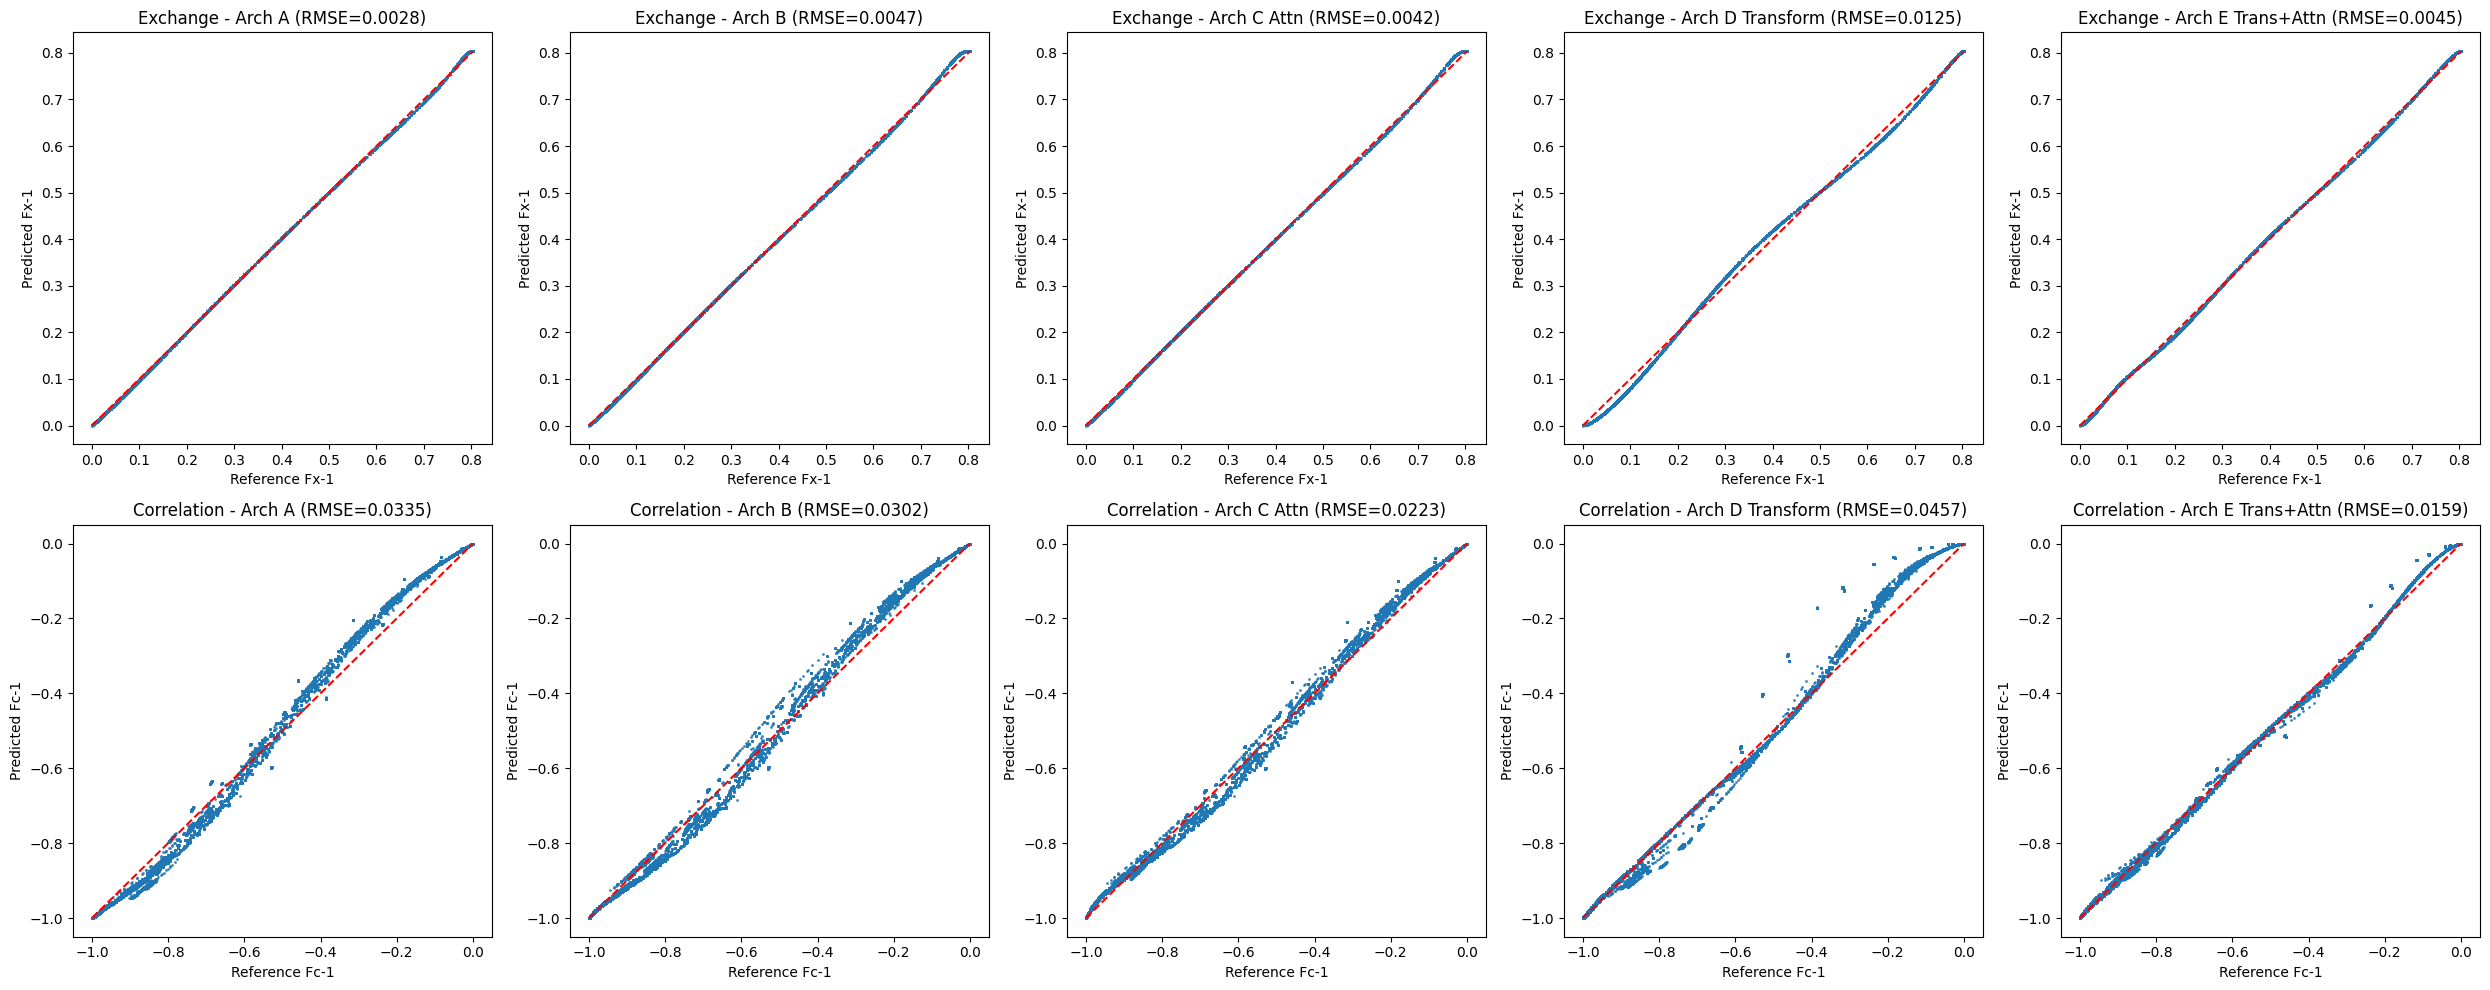

In [18]:
# Visualize pre-training results
# Note: Networks output F, but reference is F-1, so we subtract 1 from predictions
fig, axes = plt.subplots(2, 5, figsize=(25, 10))

# Exchange - Architecture A
ax = axes[0, 0]
pred_A = jax.vmap(xnet_A_trained)(train_desc_x) - 1.0
ax.scatter(train_Fx, pred_A, alpha=0.5, s=1)
ax.plot([train_Fx.min(), train_Fx.max()], [train_Fx.min(), train_Fx.max()], 'r--')
ax.set_xlabel('Reference Fx-1')
ax.set_ylabel('Predicted Fx-1')
ax.set_title(f'Exchange - Arch A (RMSE={rmse_Fx_A:.4f})')

# Exchange - Architecture B
ax = axes[0, 1]
pred_B = jax.vmap(xnet_B_trained)(train_desc_x) - 1.0
ax.scatter(train_Fx, pred_B, alpha=0.5, s=1)
ax.plot([train_Fx.min(), train_Fx.max()], [train_Fx.min(), train_Fx.max()], 'r--')
ax.set_xlabel('Reference Fx-1')
ax.set_ylabel('Predicted Fx-1')
ax.set_title(f'Exchange - Arch B (RMSE={rmse_Fx_B:.4f})')

# Exchange - Architecture C (Self-Attention)
ax = axes[0, 2]
pred_C = jax.vmap(xnet_C_trained)(train_desc_x) - 1.0
ax.scatter(train_Fx, pred_C, alpha=0.5, s=1)
ax.plot([train_Fx.min(), train_Fx.max()], [train_Fx.min(), train_Fx.max()], 'r--')
ax.set_xlabel('Reference Fx-1')
ax.set_ylabel('Predicted Fx-1')
ax.set_title(f'Exchange - Arch C Attn (RMSE={rmse_Fx_C:.4f})')

# Exchange - Architecture D (Transform)
ax = axes[0, 3]
pred_D = jax.vmap(xnet_D_trained)(train_desc_x) - 1.0
ax.scatter(train_Fx, pred_D, alpha=0.5, s=1)
ax.plot([train_Fx.min(), train_Fx.max()], [train_Fx.min(), train_Fx.max()], 'r--')
ax.set_xlabel('Reference Fx-1')
ax.set_ylabel('Predicted Fx-1')
ax.set_title(f'Exchange - Arch D Transform (RMSE={rmse_Fx_D:.4f})')

# Exchange - Architecture E (Transform + Attention)
ax = axes[0, 4]
pred_E = jax.vmap(xnet_E_trained)(train_desc_x) - 1.0
ax.scatter(train_Fx, pred_E, alpha=0.5, s=1)
ax.plot([train_Fx.min(), train_Fx.max()], [train_Fx.min(), train_Fx.max()], 'r--')
ax.set_xlabel('Reference Fx-1')
ax.set_ylabel('Predicted Fx-1')
ax.set_title(f'Exchange - Arch E Trans+Attn (RMSE={rmse_Fx_E:.4f})')

# Correlation - Architecture A
ax = axes[1, 0]
pred_A = jax.vmap(cnet_A_trained)(train_desc_c) - 1.0
ax.scatter(train_Fc, pred_A, alpha=0.5, s=1)
ax.plot([train_Fc.min(), train_Fc.max()], [train_Fc.min(), train_Fc.max()], 'r--')
ax.set_xlabel('Reference Fc-1')
ax.set_ylabel('Predicted Fc-1')
ax.set_title(f'Correlation - Arch A (RMSE={rmse_Fc_A:.4f})')

# Correlation - Architecture B
ax = axes[1, 1]
pred_B = jax.vmap(cnet_B_trained)(train_desc_c) - 1.0
ax.scatter(train_Fc, pred_B, alpha=0.5, s=1)
ax.plot([train_Fc.min(), train_Fc.max()], [train_Fc.min(), train_Fc.max()], 'r--')
ax.set_xlabel('Reference Fc-1')
ax.set_ylabel('Predicted Fc-1')
ax.set_title(f'Correlation - Arch B (RMSE={rmse_Fc_B:.4f})')

# Correlation - Architecture C (Self-Attention)
ax = axes[1, 2]
pred_C = jax.vmap(cnet_C_trained)(train_desc_c) - 1.0
ax.scatter(train_Fc, pred_C, alpha=0.5, s=1)
ax.plot([train_Fc.min(), train_Fc.max()], [train_Fc.min(), train_Fc.max()], 'r--')
ax.set_xlabel('Reference Fc-1')
ax.set_ylabel('Predicted Fc-1')
ax.set_title(f'Correlation - Arch C Attn (RMSE={rmse_Fc_C:.4f})')

# Correlation - Architecture D (Transform)
ax = axes[1, 3]
pred_D = jax.vmap(cnet_D_trained)(train_desc_c) - 1.0
ax.scatter(train_Fc, pred_D, alpha=0.5, s=1)
ax.plot([train_Fc.min(), train_Fc.max()], [train_Fc.min(), train_Fc.max()], 'r--')
ax.set_xlabel('Reference Fc-1')
ax.set_ylabel('Predicted Fc-1')
ax.set_title(f'Correlation - Arch D Transform (RMSE={rmse_Fc_D:.4f})')

# Correlation - Architecture E (Transform + Attention)
ax = axes[1, 4]
pred_E = jax.vmap(cnet_E_trained)(train_desc_c) - 1.0
ax.scatter(train_Fc, pred_E, alpha=0.5, s=1)
ax.plot([train_Fc.min(), train_Fc.max()], [train_Fc.min(), train_Fc.max()], 'r--')
ax.set_xlabel('Reference Fc-1')
ax.set_ylabel('Predicted Fc-1')
ax.set_title(f'Correlation - Arch E Trans+Attn (RMSE={rmse_Fc_E:.4f})')

plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_BASE, 'pretrain_comparison_all_architectures.png'), dpi=150)
print(f'Saved figure to {CHECKPOINT_BASE}/pretrain_comparison_all_architectures.png')
plt.show()


---
## 3. Training Part I: Total Energies and Atomization Energies

Now we fine-tune the pre-trained networks on:
1. Total energies of atoms (compared to reference CCSD or high-accuracy DFT)
2. Atomization energies of small molecules

We use PySCF-AD to enable gradient-based optimization through the SCF cycle.

In [19]:
# Create combined XC model from pre-trained networks
# We'll use Architecture B (deeper network) for training

def lda_c_pw(rhoa, rhob):
    '''PW92 LDA correlation for spin-polarized systems.'''
    params_a_pp = [1, 1, 1]
    params_a_a = [0.031091, 0.015545, 0.016887]
    params_a_alpha1 = [0.21370, 0.20548, 0.11125]
    params_a_beta1 = [7.5957, 14.1189, 10.357]
    params_a_beta2 = [3.5876, 6.1977, 3.6231]
    params_a_beta3 = [1.6382, 3.3662, 0.88026]
    params_a_beta4 = [0.49294, 0.62517, 0.49671]
    params_a_fz20 = 1.709921

    rho = rhoa + rhob
    zeta = (rhoa - rhob) / (rhoa + rhob + 1e-8)
    rs = (4 * jnp.pi * (rho + 1e-8) / 3)**(-1/3)

    def g_aux(k, rs):
        return params_a_beta1[k] * jnp.sqrt(rs) + params_a_beta2[k] * rs \
            + params_a_beta3[k] * rs**1.5 + params_a_beta4[k] * rs**(params_a_pp[k] + 1)

    def g(k, rs):
        return -2 * params_a_a[k] * (1 + params_a_alpha1[k] * rs) \
            * jnp.log(1 + 1 / (2 * params_a_a[k] * g_aux(k, rs)))

    def f_zeta(zeta):
        return ((1 + zeta)**(4/3) + (1 - zeta)**(4/3) - 2) / (2**(4/3) - 2)

    def f_pw(rs, zeta):
        return g(0, rs) + zeta**4 * f_zeta(zeta) * (g(1, rs) - g(0, rs) + g(2, rs) / params_a_fz20) \
            - f_zeta(zeta) * g(2, rs) / params_a_fz20

    return f_pw(rs, zeta)


class RXCModel_GGA(eqx.Module):
    '''
    Combined GGA XC model with exchange and correlation networks.
    
    Computes epsilon = rho * e_xc where e_xc = ex_lda * Fx + ec_lda * Fc.
    Works with both unpolarized and spin-polarized inputs.
    
    Input format: (N, D) where D=2 for unpolarized, D=5 for polarized, N=grid points
    Each row is one grid point: [rho, sigma] or [rho_a, rho_b, sigma_aa, sigma_ab, sigma_bb]
    
    The networks expect one grid point at a time, so vmap is used internally.
    '''
    xnet: eqx.Module
    cnet: eqx.Module

    def __init__(self, xnet, cnet):
        self.xnet = xnet
        self.cnet = cnet
    
    def _eval_single_point_unpol(self, point):
        '''Evaluate epsilon for a single unpolarized grid point.'''
        rho = point[0]
        sigma = point[1]
        
        ex_lda = lda_x(rho)
        ec_pw92 = pw92c_unpolarized(rho)
        
        rho_safe = jnp.maximum(rho, 1e-18)
        # Networks expect [rho, sigma] as input
        Fx = self.xnet(point)
        Fc = self.cnet(point)
        epsilon = rho_safe * (ex_lda * Fx + ec_pw92 * Fc)
        return epsilon
    
    def _eval_single_point_pol(self, point):
        '''Evaluate epsilon for a single polarized grid point.'''
        rho_a = point[0]
        rho_b = point[1]
        sigma_aa = point[2]
        sigma_ab = point[3]
        sigma_bb = point[4]
        
        rho = rho_a + rho_b
        sigma = sigma_aa + 2*sigma_ab + sigma_bb
        
        ex_lda = lda_x(rho)
        ec_pw92 = lda_c_pw(rho_a, rho_b)
        
        rho_safe = jnp.maximum(rho, 1e-18)
        # Networks expect [rho, sigma] - combine for network input
        net_input = jnp.array([rho, sigma])
        Fx = self.xnet(net_input)
        Fc = self.cnet(net_input)
        epsilon = rho_safe * (ex_lda * Fx + ec_pw92 * Fc)
        return epsilon
        
    def __call__(self, inputs):
        '''
        Compute epsilon = rho * e_xc.
        
        :param inputs: Shape (N, 2) for unpolarized or (N, 5) for polarized
                       Each row is one grid point
        :return: epsilon array of shape (N,)
        '''
        inputs = jnp.atleast_2d(inputs)
        
        # Check second dimension to determine polarization
        if inputs.shape[-1] == 2:
            # Unpolarized case: inputs shape (N, 2) with [rho, sigma] per row
            epsilon = jax.vmap(self._eval_single_point_unpol)(inputs)
            
        elif inputs.shape[-1] == 5:
            # Polarized case: inputs shape (N, 5) 
            epsilon = jax.vmap(self._eval_single_point_pol)(inputs)
        else:
            raise ValueError(f"Unexpected input shape: {inputs.shape}. Expected (N, 2) or (N, 5)")
        
        return jnp.squeeze(epsilon)


# Create the XC model from pre-trained networks
xcmodel = RXCModel_GGA(xnet=xnet_B_trained, cnet=cnet_B_trained)
print("Created combined XC model from pre-trained Architecture B networks")

Created combined XC model from pre-trained Architecture B networks


In [20]:
# Training data: atoms and small molecules with reference energies
# Use pyscf-ad (gto_ad) for autodifferentiable molecules

# Define systems with atom specifications
training_systems = [
    # Atoms
    {'name': 'H', 'atoms': 'H 0 0 0', 'spin': 1, 'charge': 0, 'type': 'atom'},
    {'name': 'O', 'atoms': 'O 0 0 0', 'spin': 2, 'charge': 0, 'type': 'atom'},
    # Molecules
    {'name': 'H2O', 'atoms': 'O 0 0 0; H 0 0.757 0.587; H 0 -0.757 0.587', 
     'spin': 0, 'charge': 0, 'type': 'molecule', 'composition': {'H': 2, 'O': 1}},
]

# Reference energies (Hartree) - these are the TRAINING TARGETS
# H: -0.5 Ha (exact)
# O: -75.0673 Ha (high-level reference)
# H2O atomization: ~974.94 kJ/mol = ~0.371 Ha
kjMol_to_H = 2625.5
refs = {
    'H_TE': -0.5,
    'O_TE': -75.0673,
    'H2O_AE': -974.94 / kjMol_to_H  # Atomization energy (negative = exothermic)
}

# Build pyscf-ad molecules (autodifferentiable)
print("Building pyscf-ad molecules for training...")
mols_ad = []
mol_names = []

for system in training_systems:
    mol = gto_ad.Mole()
    mol.atom = system['atoms']
    mol.basis = BASIS
    mol.charge = system['charge']
    mol.spin = system['spin']
    mol.build()
    mol.max_memory = 32000
    mols_ad.append(mol)
    mol_names.append(system['name'])
    print(f"  Built {system['name']}: {mol.nelectron} electrons, spin={system['spin']}")

print(f"\nTotal {len(mols_ad)} molecules for training")
print(f"Reference energies (training targets): {refs}")

# =============================================================================
# Compute CCSD reference densities and density matrices for density training
# Strategy: Use pyscf-ad for grids (consistency with training), regular pyscf for CCSD
# Note: Energy targets are from literature, only density targets come from CCSD
# =============================================================================
print("\n" + "="*60)
print("Computing CCSD reference densities and density matrices...")
print("(Grids from pyscf-ad, CCSD densities from pyscf)")
print("="*60)

from pyscf import cc

ref_densities = {}  # Grid densities from CCSD
ref_dms = {}        # Density matrices from CCSD

for i, system in enumerate(training_systems):
    name = system['name']
    mol_ad = mols_ad[i]  # pyscf-ad molecule
    
    print(f"\n  Computing reference for {name}...")
    
    # Step 1: Create pyscf-ad DFT object to get the grid (matches training)
    if mol_ad.spin == 0:
        mf_grid = dft_ad.RKS(mol_ad)
    else:
        mf_grid = dft_ad.UKS(mol_ad)
    mf_grid.grids.level = GRID_LEVEL
    mf_grid.grids.build()
    
    # Extract grid coordinates and weights from pyscf-ad
    grid_coords = np.array(mf_grid.grids.coords)
    grid_weights = np.array(mf_grid.grids.weights)
    print(f"    Grid from pyscf-ad: {len(grid_weights)} points")
    
    # Step 2: Build regular pyscf molecule for CCSD calculation
    mol_pyscf = gto.Mole()
    mol_pyscf.atom = system['atoms']
    mol_pyscf.basis = BASIS
    mol_pyscf.charge = system['charge']
    mol_pyscf.spin = system['spin']
    mol_pyscf.build()
    
    # Step 3: Run HF with regular pyscf
    if mol_pyscf.spin == 0:
        mf_hf = scf.RHF(mol_pyscf)
    else:
        mf_hf = scf.UHF(mol_pyscf)
    mf_hf.verbose = 0
    mf_hf.kernel()
    print(f"    HF energy: {mf_hf.e_tot:.6f} Ha")
    
    # Step 4: Run CCSD with regular pyscf
    if mol_pyscf.spin == 0:
        mycc = cc.CCSD(mf_hf)
    else:
        mycc = cc.UCCSD(mf_hf)
    mycc.verbose = 0
    mycc.kernel()
    print(f"    CCSD energy: {mf_hf.e_tot + mycc.e_corr:.6f} Ha")
    
    # Step 5: Get CCSD density matrix
    dm_cc = mycc.make_rdm1()
    
    # Handle spin cases
    if isinstance(dm_cc, tuple) or (hasattr(dm_cc, 'ndim') and dm_cc.ndim == 3):
        if isinstance(dm_cc, tuple):
            dm_total = dm_cc[0] + dm_cc[1]
        else:
            dm_total = dm_cc[0] + dm_cc[1]
    else:
        dm_total = dm_cc
    
    # Store density matrix as JAX array
    ref_dms[name] = jnp.array(dm_total)
    
    # Step 6: Evaluate CCSD density on pyscf-ad grid using pyscf numint
    # This ensures the density is evaluated on the exact same grid used in training
    ao = mf_grid._numint.eval_ao(mol_ad, grid_coords, deriv=0)
    rho_ref = mf_grid._numint.eval_rho(mol_ad, ao, dm_total, xctype='LDA')
    
    ref_densities[name] = {
        'rho': jnp.array(rho_ref),
        'weights': jnp.array(grid_weights),
        'coords': jnp.array(grid_coords),
        'ngrids': len(rho_ref)
    }
    
    print(f"    {name}: {len(rho_ref)} grid points, DM shape = {dm_total.shape}")

print(f"\nCCSD reference data computed for: {list(ref_densities.keys())}")
print("Note: Energy targets from literature, density targets from CCSD on pyscf-ad grids")


Building pyscf-ad molecules for training...
  Built H: 1 electrons, spin=1
  Built O: 8 electrons, spin=2
  Built H2O: 10 electrons, spin=0

Total 3 molecules for training
Reference energies (training targets): {'H_TE': -0.5, 'O_TE': -75.0673, 'H2O_AE': -0.37133498381260716}

Computing CCSD reference densities and density matrices...
(Grids from pyscf-ad, CCSD densities from pyscf)

  Computing reference for H...
    Grid from pyscf-ad: 2472 points
    HF energy: -0.466582 Ha
    CCSD energy: -0.466582 Ha
    H: 2472 grid points, DM shape = (1, 1)

  Computing reference for O...
    Grid from pyscf-ad: 5184 points
    HF energy: -73.804150 Ha
    CCSD energy: -73.804150 Ha
    O: 5184 grid points, DM shape = (5, 5)

  Computing reference for H2O...
    Grid from pyscf-ad: 10128 points
    HF energy: -74.963063 Ha
    CCSD energy: -75.012531 Ha
    H2O: 10128 grid points, DM shape = (7, 7)

CCSD reference data computed for: ['H', 'O', 'H2O']
Note: Energy targets from literature, density

In [21]:
# Define the custom eval_xc_gga_j2 function from gga_pol_dev.ipynb
# This handles BOTH polarized and unpolarized cases properly
# Uses vmap internally for per-grid-point network evaluation

def eval_xc_gga_j2(xc_code, rho, spin=0, relativity=0, deriv=1, omega=None, verbose=None,
                   xcmodel=None):
    '''
    Evaluate GGA exchange-correlation using a neural network model.
    
    Handles both spin-polarized and unpolarized cases.
    Uses vmap internally for per-grid-point evaluation.
    
    :param xc_code: XC functional code (ignored)
    :param rho: Density and gradients from PySCF
    :param spin: Spin polarization flag
    :param xcmodel: Combined XC model (RXCModel_GGA)
    :return: (exc, vxc, fxc, kxc)
    '''
    # Detect if spin-polarized by checking if rho is a tuple/list
    try:
        # Try unpolarized first
        rho0, dx, dy, dz = rho[:4]
        sigma = jnp.array(dx**2 + dy**2 + dz**2)
        rho0 = jnp.array(rho0)
        is_polarized = False
    except (ValueError, TypeError):
        # Spin-polarized: rho = [rho_a, rho_b]
        rho_a, rho_b = rho
        rho0a, dxa, dya, dza = rho_a[:4]
        rho0b, dxb, dyb, dzb = rho_b[:4]
        
        rho0 = rho0a + rho0b
        sigma_aa = dxa**2 + dya**2 + dza**2
        sigma_ab = dxa*dxb + dya*dyb + dza*dzb  
        sigma_bb = dxb**2 + dyb**2 + dzb**2
        is_polarized = True
    
    if not is_polarized:
        # ============ UNPOLARIZED CASE ============
        # Stack as (N, 2) - each row is one grid point [rho, sigma]
        rhosig = jnp.stack([rho0, sigma], axis=1)  # Shape (N, 2)
        
        # Compute exc = epsilon / rho (model uses vmap internally)
        epsilon = xcmodel(rhosig)
        exc = epsilon / (rho0 + 1e-18)
        
        # First derivatives using vmap over grid points
        # Each point is (2,) with [rho, sigma]
        def single_point_model(point):
            return xcmodel(point.reshape(1, 2)).squeeze()
        
        vrho_f = eqx.filter_grad(single_point_model)
        v1 = jnp.array(jax.vmap(vrho_f)(rhosig))  # Shape (N, 2)
        vrho = v1[:, 0]
        vsigma = v1[:, 1]
        vxc = (vrho, vsigma, None, None)
        
        # Second derivatives (Hessian)
        v2_f = jax.hessian(single_point_model)
        v2 = jnp.array(jax.vmap(v2_f)(rhosig))  # Shape (N, 2, 2)
        
        v2rho2 = v2[:, 0, 0]
        v2rhosigma = v2[:, 0, 1]
        v2sigma2 = v2[:, 1, 1]
        
        fxc = (v2rho2, v2rhosigma, v2sigma2, 
               None, None, None, None, None, None, None)
        kxc = None
        
    else:
        # ============ POLARIZED CASE ============
        # Stack as (N, 5) - each row is one grid point
        rhosig = jnp.stack([rho0a, rho0b, sigma_aa, sigma_ab, sigma_bb], axis=1)  # Shape (N, 5)
        
        # Compute exc (model uses vmap internally)
        epsilon = xcmodel(rhosig)
        exc = epsilon / (rho0 + 1e-18)
        
        # First derivatives
        def single_point_model_pol(point):
            return xcmodel(point.reshape(1, 5)).squeeze()
        
        vrho_f = eqx.filter_grad(single_point_model_pol)
        v1 = jnp.array(jax.vmap(vrho_f)(rhosig))  # Shape (N, 5)
        
        # vrho = [vrho_a, vrho_b]
        vrho = jnp.stack([v1[:, 0], v1[:, 1]], axis=1)
        # vsigma = [vsigma_aa, vsigma_ab, vsigma_bb]
        vsigma = jnp.stack([v1[:, 2], v1[:, 3], v1[:, 4]], axis=1)
        vxc = (vrho, vsigma, None, None)
        
        # Second derivatives
        v2_f = jax.hessian(single_point_model_pol)
        v2 = jnp.array(jax.vmap(v2_f)(rhosig))  # Shape (N, 5, 5)
        
        # v2rho2 = [aa, ab, bb]
        v2rho2 = jnp.stack([v2[:, 0, 0], v2[:, 0, 1], v2[:, 1, 1]], axis=1)
        
        # v2rhosigma = [a-aa, a-ab, a-bb, b-aa, b-ab, b-bb]
        v2rhosigma = jnp.stack([
            v2[:, 0, 2], v2[:, 0, 3], v2[:, 0, 4],
            v2[:, 1, 2], v2[:, 1, 3], v2[:, 1, 4]
        ], axis=1)
        
        # v2sigma2 = [aa-aa, aa-ab, aa-bb, ab-ab, ab-bb, bb-bb]
        v2sigma2 = jnp.stack([
            v2[:, 2, 2], v2[:, 2, 3], v2[:, 2, 4],
            v2[:, 3, 3], v2[:, 3, 4], v2[:, 4, 4]
        ], axis=1)
        
        fxc = (v2rho2, v2rhosigma, v2sigma2,
               None, None, None, None, None, None, None)
        kxc = None
    
    return exc, vxc, fxc, kxc

print("Defined custom eval_xc_gga_j2 (from gga_pol_dev.ipynb)")
print("This handles both polarized and unpolarized cases")
print("Input format: (N, D) where D=2 (unpolarized) or D=5 (polarized)")

Defined custom eval_xc_gga_j2 (from gga_pol_dev.ipynb)
This handles both polarized and unpolarized cases
Input format: (N, D) where D=2 (unpolarized) or D=5 (polarized)


In [22]:
# Define the loss function that runs SCF through pyscf-ad
# This is the key: mf.kernel() runs the actual SCF cycle with autodiff

@eqx.filter_value_and_grad
def energy_loss(model, mols, refs):
    '''
    Loss function for training on total energies and atomization energies.
    
    Runs actual SCF calculations through pyscf-ad for automatic differentiation.
    Uses eval_xc_gga_j2 from xcquinox.pyscf as the XC evaluator.
    
    :param model: XC model (RXCModel_GGA)
    :param mols: List of pyscf-ad Mole objects [H, O, H2O]
    :param refs: Dict of reference energies
    :return: Total loss value
    '''
    preds = []
    
    for idx, mol in enumerate(mols):
        # Select RKS or UKS based on spin
        if mol.spin:
            mf = dft_ad.UKS(mol)
        else:
            mf = dft_ad.RKS(mol)
        
        # Configure calculation for stability during training
        mf.grids.level = GRID_LEVEL  # Use low grid for speed
        mf.diis = False  # DIIS can cause issues with autodiff
        mf.damp = 0.5    # Damping for stability
        mf.max_cycle = 25
        
        # Set custom XC functional using eval_xc_gga_j2 from xcquinox.pyscf
        custom_eval_xc = partial(eval_xc_gga_j2, xcmodel=model)
        mf.define_xc_(custom_eval_xc, 'GGA')
        
        # Run SCF - this is where gradients flow through!
        pred = mf.kernel()
        preds.append(pred)
        
        jax.debug.print("Mol {idx}: E = {pred}", idx=idx, pred=pred)
    
    E_H, E_O, E_H2O = preds
    
    # Compute atomization energy: AE = E(H2O) - 2*E(H) - E(O)
    pred_AE = E_H2O - 2*E_H - E_O
    ref_AE = refs['H2O_AE']
    
    # Loss components
    AE_loss = jnp.sqrt((pred_AE - ref_AE)**2)
    H_loss = jnp.sqrt((E_H - refs['H_TE'])**2)
    O_loss = jnp.sqrt((E_O - refs['O_TE'])**2)
    
    # Combined loss with atomization energy weighted heavily
    total_loss = 50.0 * AE_loss + H_loss + O_loss
    
    jax.debug.print("AE: pred={pred}, ref={ref}, error={err}", 
                   pred=pred_AE, ref=ref_AE, err=AE_loss)
    jax.debug.print("Total loss: {loss}", loss=total_loss)
    
    return total_loss

print("Defined energy loss function with pyscf-ad SCF using eval_xc_gga_j2")

Defined energy loss function with pyscf-ad SCF using eval_xc_gga_j2


In [23]:
if not SKIP_TRAINING:
    print("\n" + "="*60)
    print("Training on Total Energies (PySCF-AD SCF)")
    print("="*60)

    TRAIN_STEPS = 25
    TRAIN_LR_INIT = 5e-3
    TRAIN_LR_END = 1e-5

    lr_scheduler = optax.linear_schedule(
        init_value=TRAIN_LR_INIT, end_value=TRAIN_LR_END,
        transition_steps=TRAIN_STEPS - 12, transition_begin=12)
    train_optimizer = optax.chain(
        optax.clip_by_global_norm(1.0), optax.adam(learning_rate=lr_scheduler))

    energy_trainer = Optimizer(
        model=xcmodel, optim=train_optimizer, mols=mols_ad, refs=refs,
        loss=energy_loss, print_every=5, steps=TRAIN_STEPS)

    xcmodel_trained, training_losses = energy_trainer()

    eqx.tree_serialise_leaves(
        os.path.join(CHECKPOINT_DIRS['train_energy'], 'xcmodel_energy.eqx'), xcmodel_trained)
    print(f"Saved to {CHECKPOINT_DIRS['train_energy']}/xcmodel_trained.eqx")
else:
    print("Loading energy-trained model from checkpoint...")
    xcmodel_trained = load_checkpoint_if_exists(
        os.path.join(CHECKPOINT_DIRS['train_energy'], 'xcmodel_energy.eqx'), xcmodel, "xcmodel_energy")


Loading energy-trained model from checkpoint...
  Loaded xcmodel_energy


### Energy-Only Training with Self-Attention Networks

Now we train the self-attention architecture (Architecture C) using the same energy-only loss function.

In [24]:
# Create XC model with self-attention networks (Architecture C)
xcmodel_attn = RXCModel_GGA(xnet=xnet_C_trained, cnet=cnet_C_trained)
print("Created combined XC model from pre-trained Architecture C networks (with self-attention)")

Created combined XC model from pre-trained Architecture C networks (with self-attention)


In [25]:
if not SKIP_TRAINING:
    print("\n" + "="*60)
    print("Training Self-Attention Networks on Total Energies")
    print("="*60)

    train_optimizer_attn = optax.chain(
        optax.clip_by_global_norm(1.0), optax.adam(learning_rate=lr_scheduler))

    energy_trainer_attn = Optimizer(
        model=xcmodel_attn, optim=train_optimizer_attn, mols=mols_ad, refs=refs,
        loss=energy_loss, print_every=5, steps=TRAIN_STEPS)

    xcmodel_attn_trained, training_losses_attn = energy_trainer_attn()

    eqx.tree_serialise_leaves(
        os.path.join(CHECKPOINT_DIRS['train_energy_attn'], 'xcmodel_energy_attn.eqx'), xcmodel_attn_trained)
else:
    print("Loading energy-trained attention model from checkpoint...")
    xcmodel_attn_trained = load_checkpoint_if_exists(
        os.path.join(CHECKPOINT_DIRS['train_energy_attn'], 'xcmodel_energy_attn.eqx'), xcmodel_attn, "xcmodel_energy_attn")


Loading energy-trained attention model from checkpoint...
  Loaded xcmodel_energy_attn


---
## 4. Training Part II: Including Density Error

Now we add density error to the loss function. This penalizes deviations in the predicted electron density from a reference (e.g., CCSD density).

In [26]:
# Define loss function that includes density matrix error vs CCSD reference
# This compares the predicted DM to CCSD DM, not just regularizing the norm

@eqx.filter_value_and_grad
def energy_density_loss(model, mols, refs, ref_dms, mol_names, energy_weight=1.0, density_weight=1.0):
    '''
    Loss function that combines energy error and density matrix error vs CCSD.
    
    Energy targets: manually specified reference energies (H=-0.5, O=-75.0673, etc.)
    Density targets: CCSD density matrices
    
    Both components are normalized to be O(1) before applying weights,
    so energy_weight and density_weight directly control relative importance.
    
    :param model: XC model (RXCModel_GGA)
    :param mols: List of pyscf-ad Mole objects [H, O, H2O]
    :param refs: Dict of reference energies (training targets)
    :param ref_dms: Dict of CCSD reference density matrices (density targets)
    :param mol_names: List of molecule names
    :param energy_weight: Weight for energy loss component (default 1.0)
    :param density_weight: Weight for density loss component (default 1.0)
    :return: Total loss value
    '''
    preds = []
    dm_errors = []
    
    for idx, (mol, name) in enumerate(zip(mols, mol_names)):
        # Select RKS or UKS based on spin
        if mol.spin:
            mf = dft_ad.UKS(mol)
        else:
            mf = dft_ad.RKS(mol)
        
        # Configure calculation
        mf.grids.level = GRID_LEVEL
        mf.diis = False
        mf.damp = 0.5
        mf.max_cycle = 25
        
        # Set custom XC functional using eval_xc_gga_j2 from xcquinox.pyscf
        custom_eval_xc = partial(eval_xc_gga_j2, xcmodel=model)
        mf.define_xc_(custom_eval_xc, 'GGA')
        
        # Run SCF
        pred = mf.kernel()
        preds.append(pred)
        
        # Get predicted density matrix
        dm = mf.make_rdm1()
        if dm.ndim == 3:  # UKS
            dm_total = dm[0] + dm[1]
        else:
            dm_total = dm
        
        # Compare to CCSD reference DM
        # Normalize by number of elements for scale-invariance
        dm_ref = ref_dms[name]
        dm_diff = dm_total - dm_ref
        n_elements = dm_diff.shape[0] * dm_diff.shape[1]
        dm_error = jnp.sum(dm_diff**2) / n_elements  # Mean squared error
        dm_errors.append(dm_error)
        
        jax.debug.print("Mol {name}: E = {pred:.6f}, DM_MSE = {dme:.8f}", 
                       name=name, pred=pred, dme=dm_error)
    
    E_H, E_O, E_H2O = preds
    
    # Compute atomization energy
    pred_AE = E_H2O - 2*E_H - E_O
    ref_AE = refs['H2O_AE']
    
    # Energy loss components (using reference energies as targets)
    # Scale by typical error magnitude to normalize to O(1)
    AE_loss = jnp.abs(pred_AE - ref_AE) / 0.01  # 10 mHa scale
    H_loss = jnp.abs(E_H - refs['H_TE']) / 0.01
    O_loss = jnp.abs(E_O - refs['O_TE']) / 0.1  # O has larger errors
    
    # Normalized energy loss (each component is O(1) for typical errors)
    energy_loss_val = (AE_loss + H_loss + O_loss) / 3.0
    
    # Density loss: mean of DM MSEs (already normalized per element)
    # Scale up since MSE of DM differences is typically ~1e-4 to 1e-3
    density_loss_val = jnp.mean(jnp.array(dm_errors)) * 1000.0
    
    # Combined loss - weights now directly control relative importance
    total_loss = energy_weight * energy_loss_val + density_weight * density_loss_val
    
    jax.debug.print("Energy loss (norm): {el:.4f}, Density loss (norm): {dl:.4f}, Total: {tl:.4f}",
                   el=energy_loss_val, dl=density_loss_val, tl=total_loss)
    
    return total_loss


# =============================================================================
# MOLECULE-ONLY LOSS FUNCTIONS
# These exclude atomic density errors which are problematic for spin-polarized atoms
# =============================================================================

@eqx.filter_value_and_grad
def energy_mol_dm_loss(model, mols, refs, ref_dms, mol_names, energy_weight=1.0, density_weight=1.0):
    '''
    Loss function that combines energy error and MOLECULAR density matrix error only.
    
    Excludes atomic density errors (H, O) which are problematic for spin-polarized atoms.
    Only includes H2O density matrix error.
    
    Energy targets: manually specified reference energies
    Density targets: CCSD density matrix for H2O only
    
    :param model: XC model (RXCModel_GGA)
    :param mols: List of pyscf-ad Mole objects [H, O, H2O]
    :param refs: Dict of reference energies (training targets)
    :param ref_dms: Dict of CCSD reference density matrices
    :param mol_names: List of molecule names
    :param energy_weight: Weight for energy loss component (default 1.0)
    :param density_weight: Weight for density loss component (default 1.0)
    :return: Total loss value
    '''
    preds = []
    dm_errors = []
    
    for idx, (mol, name) in enumerate(zip(mols, mol_names)):
        # Select RKS or UKS based on spin
        if mol.spin:
            mf = dft_ad.UKS(mol)
        else:
            mf = dft_ad.RKS(mol)
        
        # Configure calculation
        mf.grids.level = GRID_LEVEL
        mf.diis = False
        mf.damp = 0.5
        mf.max_cycle = 25
        
        # Set custom XC functional
        custom_eval_xc = partial(eval_xc_gga_j2, xcmodel=model)
        mf.define_xc_(custom_eval_xc, 'GGA')
        
        # Run SCF
        pred = mf.kernel()
        preds.append(pred)
        
        # Only compute DM error for molecules (not atoms)
        if name == 'H2O':  # Only molecule
            dm = mf.make_rdm1()
            if dm.ndim == 3:  # UKS
                dm_total = dm[0] + dm[1]
            else:
                dm_total = dm
            
            dm_ref = ref_dms[name]
            dm_diff = dm_total - dm_ref
            n_elements = dm_diff.shape[0] * dm_diff.shape[1]
            dm_error = jnp.sum(dm_diff**2) / n_elements
            dm_errors.append(dm_error)
            
            jax.debug.print("Mol {name}: E = {pred:.6f}, DM_MSE = {dme:.8f}", 
                           name=name, pred=pred, dme=dm_error)
        else:
            jax.debug.print("Atom {name}: E = {pred:.6f} (DM excluded)", 
                           name=name, pred=pred)
    
    E_H, E_O, E_H2O = preds
    
    # Compute atomization energy
    pred_AE = E_H2O - 2*E_H - E_O
    ref_AE = refs['H2O_AE']
    
    # Energy loss components
    AE_loss = jnp.abs(pred_AE - ref_AE) / 0.01
    H_loss = jnp.abs(E_H - refs['H_TE']) / 0.01
    O_loss = jnp.abs(E_O - refs['O_TE']) / 0.1
    
    energy_loss_val = (AE_loss + H_loss + O_loss) / 3.0
    
    # Density loss: only molecular DM (H2O)
    density_loss_val = jnp.mean(jnp.array(dm_errors)) * 1000.0
    
    total_loss = energy_weight * energy_loss_val + density_weight * density_loss_val
    
    jax.debug.print("Energy loss (norm): {el:.4f}, Mol DM loss (norm): {dl:.4f}, Total: {tl:.4f}",
                   el=energy_loss_val, dl=density_loss_val, tl=total_loss)
    
    return total_loss


@eqx.filter_value_and_grad
def energy_mol_grid_density_loss(model, mols, refs, ref_densities, mol_names,
                                  energy_weight=1.0, density_weight=1.0):
    '''
    Loss function combining energy error and MOLECULAR grid density error only.
    
    Excludes atomic density errors (H, O) which are problematic.
    Only includes H2O grid density error.
    
    :param model: XC model (RXCModel_GGA)
    :param mols: List of pyscf-ad Mole objects [H, O, H2O]
    :param refs: Dict of reference energies
    :param ref_densities: Dict of CCSD reference densities on grid
    :param mol_names: List of molecule names
    :param energy_weight: Weight for energy loss component (default 1.0)
    :param density_weight: Weight for density loss component (default 1.0)
    :return: Total loss value
    '''
    preds = []
    density_errors = []
    
    for idx, (mol, name) in enumerate(zip(mols, mol_names)):
        # Select RKS or UKS based on spin
        if mol.spin:
            mf = dft_ad.UKS(mol)
        else:
            mf = dft_ad.RKS(mol)
        
        # Configure calculation
        mf.grids.level = GRID_LEVEL
        mf.grids.build()
        mf.diis = False
        mf.damp = 0.5
        mf.max_cycle = 25
        
        # Set custom XC functional
        custom_eval_xc = partial(eval_xc_gga_j2, xcmodel=model)
        mf.define_xc_(custom_eval_xc, 'GGA')
        
        # Run SCF
        pred = mf.kernel()
        preds.append(pred)
        
        # Only compute density error for molecules (not atoms)
        if name == 'H2O':  # Only molecule
            ao_val = mf._numint.eval_ao(mol, mf.grids.coords, deriv=0)
            dm = mf.make_rdm1()
            
            if dm.ndim == 3:  # UKS
                dm_total = dm[0] + dm[1]
            else:
                dm_total = dm
            
            rho_pred = mf._numint.eval_rho(mol, ao_val, dm_total, xctype='LDA')
            
            rho_ref = ref_densities[name]['rho']
            weights = ref_densities[name]['weights']
            
            density_diff = rho_pred - rho_ref
            density_error = jnp.sum(weights * density_diff**2) / (jnp.sum(weights * rho_ref**2) + 1e-10)
            density_errors.append(density_error)
            
            jax.debug.print("Mol {name}: E = {pred:.6f}, rho_err_norm = {derr:.6f}", 
                           name=name, pred=pred, derr=density_error)
        else:
            jax.debug.print("Atom {name}: E = {pred:.6f} (density excluded)", 
                           name=name, pred=pred)
    
    E_H, E_O, E_H2O = preds
    
    # Compute atomization energy
    pred_AE = E_H2O - 2*E_H - E_O
    ref_AE = refs['H2O_AE']
    
    # Energy loss components
    AE_loss = jnp.abs(pred_AE - ref_AE) / 0.01
    H_loss = jnp.abs(E_H - refs['H_TE']) / 0.01
    O_loss = jnp.abs(E_O - refs['O_TE']) / 0.1
    
    energy_loss_val = (AE_loss + H_loss + O_loss) / 3.0
    
    # Normalized molecular grid density error (H2O only)
    # Scale by 1000 to match energy loss magnitude
    density_loss_val = jnp.mean(jnp.array(density_errors)) * 1000.0
    
    total_loss = energy_weight * energy_loss_val + density_weight * density_loss_val
    
    jax.debug.print("Energy loss (norm): {el:.4f}, Mol Grid Density loss (norm): {dl:.4f}, Total: {tl:.4f}",
                   el=energy_loss_val, dl=density_loss_val, tl=total_loss)
    
    return total_loss


print("Defined loss functions:")
print("  - energy_density_loss: Energy + DM error (all systems, CCSD reference)")
print("  - energy_mol_dm_loss: Energy + DM error (H2O only, CCSD reference)")
print("  - energy_mol_grid_density_loss: Energy + Grid density error (H2O only, CCSD reference)")

Defined loss functions:
  - energy_density_loss: Energy + DM error (all systems, CCSD reference)
  - energy_mol_dm_loss: Energy + DM error (H2O only, CCSD reference)
  - energy_mol_grid_density_loss: Energy + Grid density error (H2O only, CCSD reference)


In [27]:
if not SKIP_TRAINING:
    # Training with Energy + DM Error Loss (comparing to PBE density matrix)
    print("\n" + "="*60)
    print("Training with Energy + DM Error vs PBE (PySCF-AD)")
    print("="*60)
    
    # Reset model to pre-trained state for fair comparison
    xcmodel_density = RXCModel_GGA(xnet=xnet_B_trained, cnet=cnet_B_trained)
    
    # Training configuration
    # Density slightly heavier than energy (1.5x)
    TRAIN_STEPS_2 = 25
    ENERGY_WEIGHT = 1.0
    DENSITY_WEIGHT = 1.5  # Density 50% heavier than energy (losses are normalized)
    DECAY_BEGIN = 8
    # Learning rate schedule
    lr_scheduler_2 = optax.linear_schedule(
        init_value=TRAIN_LR_INIT,
        transition_steps=TRAIN_STEPS_2 - DECAY_BEGIN,
        transition_begin=DECAY_BEGIN,
        end_value=TRAIN_LR_END,
    )
    
    # Optimizer with gradient clipping
    train_optimizer_2 = optax.chain(
        optax.clip_by_global_norm(1.0),
        optax.adam(learning_rate=lr_scheduler_2)
    )
    
    # Create a partial loss function with weights and PBE reference data
    energy_density_loss_weighted = partial(
        energy_density_loss,
        ref_dms=ref_dms,
        mol_names=mol_names,
        energy_weight=ENERGY_WEIGHT, 
        density_weight=DENSITY_WEIGHT
    )
    
    print(f"\nTraining with energy_weight={ENERGY_WEIGHT}, density_weight={DENSITY_WEIGHT}")
    print(f"Energy target: reference energies, Density target: PBE DM")
    print(f"Training for {TRAIN_STEPS_2} steps with pyscf-ad...")
    
    density_trainer = Optimizer(
        model=xcmodel_density,
        optim=train_optimizer_2,
        mols=mols_ad,
        refs=refs,
        loss=energy_density_loss_weighted,
        print_every=5,
        steps=TRAIN_STEPS_2
    )
    
    # Run training
    xcmodel_density_trained, density_losses = density_trainer()
    
    print(f"\nTraining complete!")
    print(f"Final loss: {density_losses[-1]:.6f}")
    
    # Save checkpoint
    density_ckpt_dir = CHECKPOINT_DIRS['train_energy_density']
    eqx.tree_serialise_leaves(os.path.join(density_ckpt_dir, 'xcmodel_density.eqx'), xcmodel_density_trained)
    print(f"Saved trained model to {density_ckpt_dir}/xcmodel_density.eqx")
else:
    print("Loading xcmodel_density_trained from checkpoint...")
    xcmodel_density = RXCModel_GGA(xnet=xnet_B_trained, cnet=cnet_B_trained)
    xcmodel_density_trained = load_checkpoint_if_exists(
        os.path.join(CHECKPOINT_DIRS['train_energy_density'], 'xcmodel_density.eqx'),
        xcmodel_density, "xcmodel_density_trained")

Loading xcmodel_density_trained from checkpoint...
  Loaded xcmodel_density_trained


In [28]:
if not SKIP_TRAINING:
    # Training with Energy + DM Error (Higher Density Weight)
    print("\n" + "="*60)
    print("Training with Energy + DM Error vs PBE (Higher Weight)")
    print("="*60)
    
    # Reset model to pre-trained state
    xcmodel_density_hw = RXCModel_GGA(xnet=xnet_B_trained, cnet=cnet_B_trained)
    
    # Training configuration - higher density weight
    TRAIN_STEPS_HW = 25
    ENERGY_WEIGHT_HW = 1.0
    DENSITY_WEIGHT_HW = 3.0  # Density 3x heavier than energy (losses are normalized)
    
    # Learning rate schedule
    lr_scheduler_hw = optax.linear_schedule(
        init_value=TRAIN_LR_INIT,
        transition_steps=TRAIN_STEPS_HW - DECAY_BEGIN,
        transition_begin=DECAY_BEGIN,
        end_value=TRAIN_LR_END,
    )
    
    # Optimizer with gradient clipping
    train_optimizer_hw = optax.chain(
        optax.clip_by_global_norm(1.0),
        optax.adam(learning_rate=lr_scheduler_hw)
    )
    
    # Create a partial loss function with higher density weight and PBE reference
    energy_density_loss_hw = partial(
        energy_density_loss,
        ref_dms=ref_dms,
        mol_names=mol_names,
        energy_weight=ENERGY_WEIGHT_HW, 
        density_weight=DENSITY_WEIGHT_HW
    )
    
    print(f"\nTraining with energy_weight={ENERGY_WEIGHT_HW}, density_weight={DENSITY_WEIGHT_HW}")
    print(f"Energy target: reference energies, Density target: PBE DM")
    print(f"Training for {TRAIN_STEPS_HW} steps with pyscf-ad...")
    
    density_trainer_hw = Optimizer(
        model=xcmodel_density_hw,
        optim=train_optimizer_hw,
        mols=mols_ad,
        refs=refs,
        loss=energy_density_loss_hw,
        print_every=5,
        steps=TRAIN_STEPS_HW
    )
    
    # Run training
    xcmodel_density_trained_hw, density_losses_hw = density_trainer_hw()
    
    print(f"\nTraining complete!")
    print(f"Final loss: {density_losses_hw[-1]:.6f}")
    
    # Save checkpoint
    density_hw_ckpt_dir = CHECKPOINT_DIRS['train_energy_density_hw']
    eqx.tree_serialise_leaves(os.path.join(density_hw_ckpt_dir, 'xcmodel_density_hw.eqx'), xcmodel_density_trained_hw)
    print(f"Saved trained model to {density_hw_ckpt_dir}/xcmodel_density_hw.eqx")
else:
    print("Loading xcmodel_density_trained_hw from checkpoint...")
    xcmodel_density_hw = RXCModel_GGA(xnet=xnet_B_trained, cnet=cnet_B_trained)
    xcmodel_density_trained_hw = load_checkpoint_if_exists(
        os.path.join(CHECKPOINT_DIRS['train_energy_density_hw'], 'xcmodel_density_hw.eqx'),
        xcmodel_density_hw, "xcmodel_density_trained_hw")

Loading xcmodel_density_trained_hw from checkpoint...
  Loaded xcmodel_density_trained_hw


### Energy + DM Regularization with Self-Attention Networks

Training the self-attention architecture with energy + density matrix regularization loss.

In [29]:
if not SKIP_TRAINING:
    # Training with Energy + DM Error (Self-Attention Networks)
    print("\n" + "="*60)
    print("Training with Energy + DM Error vs PBE (Self-Attention)")
    print("="*60)
    
    # Reset model to pre-trained self-attention state
    xcmodel_density_attn = RXCModel_GGA(xnet=xnet_C_trained, cnet=cnet_C_trained)
    
    # Learning rate schedule
    lr_scheduler_attn = optax.linear_schedule(
        init_value=TRAIN_LR_INIT,
        transition_steps=TRAIN_STEPS_2 - DECAY_BEGIN,
        transition_begin=DECAY_BEGIN,
        end_value=TRAIN_LR_END,
    )
    
    train_optimizer_density_attn = optax.chain(
        optax.clip_by_global_norm(1.0),
        optax.adam(learning_rate=lr_scheduler_attn)
    )
    
    # Create partial loss function with weights and PBE reference
    energy_density_loss_attn = partial(
        energy_density_loss,
        ref_dms=ref_dms,
        mol_names=mol_names,
        energy_weight=ENERGY_WEIGHT, 
        density_weight=DENSITY_WEIGHT
    )
    
    print(f"\nTraining with energy_weight={ENERGY_WEIGHT}, density_weight={DENSITY_WEIGHT}")
    print(f"Energy target: reference energies, Density target: PBE DM")
    print(f"Training for {TRAIN_STEPS_2} steps with pyscf-ad (self-attention model)...")
    
    density_trainer_attn = Optimizer(
        model=xcmodel_density_attn,
        optim=train_optimizer_density_attn,
        mols=mols_ad,
        refs=refs,
        loss=energy_density_loss_attn,
        print_every=5,
        steps=TRAIN_STEPS_2
    )
    
    # Run training
    xcmodel_density_attn_trained, density_losses_attn = density_trainer_attn()
    
    print(f"\nTraining complete!")
    print(f"Final loss: {density_losses_attn[-1]:.6f}")
    
    # Save checkpoint
    density_attn_ckpt_dir = CHECKPOINT_DIRS['train_energy_density_attn']
    eqx.tree_serialise_leaves(os.path.join(density_attn_ckpt_dir, 'xcmodel_density_attn.eqx'), xcmodel_density_attn_trained)
    print(f"Saved trained model to {density_attn_ckpt_dir}/xcmodel_density_attn.eqx")
else:
    print("Loading xcmodel_density_attn_trained from checkpoint...")
    xcmodel_density_attn = RXCModel_GGA(xnet=xnet_C_trained, cnet=cnet_C_trained)
    xcmodel_density_attn_trained = load_checkpoint_if_exists(
        os.path.join(CHECKPOINT_DIRS['train_energy_density_attn'], 'xcmodel_density_attn.eqx'),
        xcmodel_density_attn, "xcmodel_density_attn_trained")

Loading xcmodel_density_attn_trained from checkpoint...
  Loaded xcmodel_density_attn_trained


### Training with Grid Density Loss

Now we train using the actual electron density evaluated on the grid, not just the density matrix norm. This compares the predicted density at each grid point to a reference density (from PBE).

In [30]:
# Verify reference densities are available from training-data cell
# (ref_densities was computed earlier using pyscf-ad with PBE)

print("Grid density training will use PBE reference densities computed in training-data cell")
print(f"Reference densities available for: {list(ref_densities.keys())}")
for name, data in ref_densities.items():
    print(f"  {name}: {data['ngrids']} grid points")


Grid density training will use PBE reference densities computed in training-data cell
Reference densities available for: ['H', 'O', 'H2O']
  H: 2472 grid points
  O: 5184 grid points
  H2O: 10128 grid points


In [31]:
# Define loss function that uses actual grid density
# This computes density on the grid and compares to reference

@eqx.filter_value_and_grad
def energy_grid_density_loss(model, mols, refs, ref_densities, mol_names,
                              energy_weight=1.0, density_weight=1.0):
    '''
    Loss function combining energy error and grid density error.
    
    Runs SCF through pyscf-ad and compares the resulting density on the grid
    to a reference density (from CCSD computed with pyscf-ad on same grid).
    
    Both components are normalized to be O(1) before applying weights,
    so energy_weight and density_weight directly control relative importance.
    
    :param model: XC model (RXCModel_GGA)
    :param mols: List of pyscf-ad Mole objects [H, O, H2O]
    :param refs: Dict of reference energies
    :param ref_densities: Dict of reference densities on grid (from CCSD)
    :param mol_names: List of molecule names matching mols order
    :param energy_weight: Weight for energy loss component (default 1.0)
    :param density_weight: Weight for density loss component (default 1.0)
    :return: Total loss value
    '''
    preds = []
    density_errors = []
    
    for idx, (mol, name) in enumerate(zip(mols, mol_names)):
        # Select RKS or UKS based on spin
        if mol.spin:
            mf = dft_ad.UKS(mol)
        else:
            mf = dft_ad.RKS(mol)
        
        # Configure calculation
        mf.grids.level = GRID_LEVEL
        mf.grids.build()
        mf.diis = False
        mf.damp = 0.5
        mf.max_cycle = 25
        
        # Set custom XC functional
        custom_eval_xc = partial(eval_xc_gga_j2, xcmodel=model)
        mf.define_xc_(custom_eval_xc, 'GGA')
        
        # Run SCF
        pred = mf.kernel()
        preds.append(pred)
        
        # Compute density on grid
        ao_val = mf._numint.eval_ao(mol, mf.grids.coords, deriv=0)
        dm = mf.make_rdm1()
        
        if dm.ndim == 3:  # UKS
            dm_total = dm[0] + dm[1]
        else:
            dm_total = dm
        
        # Compute predicted density on grid
        rho_pred = mf._numint.eval_rho(mol, ao_val, dm_total, xctype='LDA')
        
        # Get reference density and grid weights
        rho_ref = ref_densities[name]['rho']
        weights = ref_densities[name]['weights']
        
        # Compute normalized density error
        # This is integral of |rho_pred - rho_ref|^2, divided by integral of rho_ref^2
        # to make it dimensionless and scale-invariant
        density_diff = rho_pred - rho_ref
        density_error = jnp.sum(weights * density_diff**2) / (jnp.sum(weights * rho_ref**2) + 1e-10)
        density_errors.append(density_error)
        
        jax.debug.print("Mol {name}: E = {pred:.6f}, rho_err_norm = {derr:.6f}", 
                       name=name, pred=pred, derr=density_error)
    
    E_H, E_O, E_H2O = preds
    
    # Compute atomization energy
    pred_AE = E_H2O - 2*E_H - E_O
    ref_AE = refs['H2O_AE']
    
    # Energy loss components - normalized to O(1) for typical errors
    AE_loss = jnp.abs(pred_AE - ref_AE) / 0.01  # 10 mHa scale
    H_loss = jnp.abs(E_H - refs['H_TE']) / 0.01
    O_loss = jnp.abs(E_O - refs['O_TE']) / 0.1
    
    energy_loss_val = (AE_loss + H_loss + O_loss) / 3.0
    
    # Normalized grid density error (mean over molecules)
    # FIXED: Scale by 1000 to match DM loss magnitude (was 10, now 1000)
    density_loss_val = jnp.mean(jnp.array(density_errors)) * 1000.0
    
    # Combined loss
    total_loss = energy_weight * energy_loss_val + density_weight * density_loss_val
    
    jax.debug.print("Energy loss (norm): {el:.4f}, Density loss (norm): {dl:.4f}, Total: {tl:.4f}",
                   el=energy_loss_val, dl=density_loss_val, tl=total_loss)
    
    return total_loss

print("Defined energy + grid density loss function (CCSD reference)")
print("FIXED: Grid density loss now scaled by 1000x (was 10x) to match energy loss magnitude")

Defined energy + grid density loss function (CCSD reference)
FIXED: Grid density loss now scaled by 1000x (was 10x) to match energy loss magnitude


In [32]:
if not SKIP_TRAINING:
    # Training with Energy + Grid Density Loss using PySCF-AD SCF
    print("\n" + "="*60)
    print("Training with Energy + Grid Density Loss (PySCF-AD)")
    print("="*60)
    
    # Reset model to pre-trained state
    xcmodel_grid_density = RXCModel_GGA(xnet=xnet_B_trained, cnet=cnet_B_trained)
    
    # Training configuration
    TRAIN_STEPS_GRID = 25  # Reduced for debugging
    ENERGY_WEIGHT_GRID = 1.0
    DENSITY_WEIGHT_GRID = 1.5  # Density 50% heavier than energy (losses are normalized)
    
    # Learning rate schedule
    lr_scheduler_grid = optax.linear_schedule(
        init_value=TRAIN_LR_INIT,
        transition_steps=TRAIN_STEPS_GRID - DECAY_BEGIN,
        transition_begin=DECAY_BEGIN,
        end_value=TRAIN_LR_END,
    )
    
    # Optimizer with gradient clipping
    train_optimizer_grid = optax.chain(
        optax.clip_by_global_norm(1.0),
        optax.adam(learning_rate=lr_scheduler_grid)
    )
    
    # Create partial loss function with weights and reference data
    energy_grid_density_loss_partial = partial(
        energy_grid_density_loss,
        ref_densities=ref_densities,
        mol_names=mol_names,
        energy_weight=ENERGY_WEIGHT_GRID,
        density_weight=DENSITY_WEIGHT_GRID
    )
    
    print(f"\nTraining with energy_weight={ENERGY_WEIGHT_GRID}, density_weight={DENSITY_WEIGHT_GRID}")
    print(f"Training for {TRAIN_STEPS_GRID} steps with pyscf-ad...")
    print("Using actual grid density for loss (computed with pyscf-ad)")
    
    grid_density_trainer = Optimizer(
        model=xcmodel_grid_density,
        optim=train_optimizer_grid,
        mols=mols_ad,
        refs=refs,
        loss=energy_grid_density_loss_partial,
        print_every=5,
        steps=TRAIN_STEPS_GRID
    )
    
    # Run training
    xcmodel_grid_density_trained, grid_density_losses = grid_density_trainer()
    
    print(f"\nTraining complete!")
    print(f"Final loss: {grid_density_losses[-1]:.6f}")
    
    # Save checkpoint
    grid_density_ckpt_dir = CHECKPOINT_DIRS['train_grid_density']
    eqx.tree_serialise_leaves(os.path.join(grid_density_ckpt_dir, 'xcmodel_grid_density.eqx'), 
                              xcmodel_grid_density_trained)
    print(f"Saved trained model to {grid_density_ckpt_dir}/xcmodel_grid_density.eqx")
else:
    print("Loading xcmodel_grid_density_trained from checkpoint...")
    xcmodel_grid_density = RXCModel_GGA(xnet=xnet_B_trained, cnet=cnet_B_trained)
    xcmodel_grid_density_trained = load_checkpoint_if_exists(
        os.path.join(CHECKPOINT_DIRS['train_grid_density'], 'xcmodel_grid_density.eqx'),
        xcmodel_grid_density, "xcmodel_grid_density_trained")

Loading xcmodel_grid_density_trained from checkpoint...
  Loaded xcmodel_grid_density_trained


### Grid Density Training with Self-Attention Networks

Training the self-attention architecture with energy + grid density loss.

In [33]:
if not SKIP_TRAINING:
    # Training with Energy + Grid Density Loss (Self-Attention Networks)
    print("\n" + "="*60)
    print("Training with Energy + Grid Density Loss (Self-Attention)")
    print("="*60)
    
    # Reset model to pre-trained self-attention state
    xcmodel_grid_density_attn = RXCModel_GGA(xnet=xnet_C_trained, cnet=cnet_C_trained)
    
    # Learning rate schedule
    lr_scheduler_grid_attn = optax.linear_schedule(
        init_value=TRAIN_LR_INIT,
        transition_steps=TRAIN_STEPS_GRID - DECAY_BEGIN,
        transition_begin=DECAY_BEGIN,
        end_value=TRAIN_LR_END,
    )
    
    train_optimizer_grid_attn = optax.chain(
        optax.clip_by_global_norm(1.0),
        optax.adam(learning_rate=lr_scheduler_grid_attn)
    )
    
    # Create partial loss function with weights and reference data
    energy_grid_density_loss_attn = partial(
        energy_grid_density_loss,
        ref_densities=ref_densities,
        mol_names=mol_names,
        energy_weight=ENERGY_WEIGHT_GRID,
        density_weight=DENSITY_WEIGHT_GRID
    )
    
    print(f"\nTraining with energy_weight={ENERGY_WEIGHT_GRID}, density_weight={DENSITY_WEIGHT_GRID}")
    print(f"Training for {TRAIN_STEPS_GRID} steps with pyscf-ad (self-attention model)...")
    print("Using actual grid density for loss (computed with pyscf-ad)")
    
    grid_density_trainer_attn = Optimizer(
        model=xcmodel_grid_density_attn,
        optim=train_optimizer_grid_attn,
        mols=mols_ad,
        refs=refs,
        loss=energy_grid_density_loss_attn,
        print_every=5,
        steps=TRAIN_STEPS_GRID
    )
    
    # Run training
    xcmodel_grid_density_attn_trained, grid_density_losses_attn = grid_density_trainer_attn()
    
    print(f"\nTraining complete!")
    print(f"Final loss: {grid_density_losses_attn[-1]:.6f}")
    
    # Save checkpoint
    grid_density_attn_ckpt_dir = CHECKPOINT_DIRS['train_grid_density_attn']
    eqx.tree_serialise_leaves(os.path.join(grid_density_attn_ckpt_dir, 'xcmodel_grid_density_attn.eqx'), 
                              xcmodel_grid_density_attn_trained)
    print(f"Saved trained model to {grid_density_attn_ckpt_dir}/xcmodel_grid_density_attn.eqx")
else:
    print("Loading xcmodel_grid_density_attn_trained from checkpoint...")
    xcmodel_grid_density_attn = RXCModel_GGA(xnet=xnet_C_trained, cnet=cnet_C_trained)
    xcmodel_grid_density_attn_trained = load_checkpoint_if_exists(
        os.path.join(CHECKPOINT_DIRS['train_grid_density_attn'], 'xcmodel_grid_density_attn.eqx'),
        xcmodel_grid_density_attn, "xcmodel_grid_density_attn_trained")

Loading xcmodel_grid_density_attn_trained from checkpoint...
  Loaded xcmodel_grid_density_attn_trained


### Molecule-Only Density Training

The following training runs use only the **molecular density** (H2O) for the density loss,
excluding atomic densities (H, O) which are problematic for spin-polarized atoms.

This addresses the issue where atomic DM errors (especially O) oscillate wildly during training
due to UKS gradient flow issues.

In [34]:
if not SKIP_TRAINING:
    # Training with Energy + Molecule-Only DM Error Loss
    print("\n" + "="*60)
    print("Training with Energy + Molecule-Only DM Error (Standard)")
    print("="*60)
    
    # Reset model to pre-trained state
    xcmodel_mol_dm = RXCModel_GGA(xnet=xnet_B_trained, cnet=cnet_B_trained)
    
    # Training configuration
    TRAIN_STEPS_MOL = 25
    ENERGY_WEIGHT_MOL = 1.0
    DENSITY_WEIGHT_MOL = 1.5  # Density 50% heavier than energy
    
    # Learning rate schedule
    lr_scheduler_mol = optax.linear_schedule(
        init_value=TRAIN_LR_INIT,
        transition_steps=TRAIN_STEPS_MOL - DECAY_BEGIN,
        transition_begin=DECAY_BEGIN,
        end_value=TRAIN_LR_END,
    )
    
    # Optimizer with gradient clipping
    train_optimizer_mol_dm = optax.chain(
        optax.clip_by_global_norm(1.0),
        optax.adam(learning_rate=lr_scheduler_mol)
    )
    
    # Create partial loss function with CCSD reference and molecule-only density
    energy_mol_dm_loss_partial = partial(
        energy_mol_dm_loss,
        ref_dms=ref_dms,
        mol_names=mol_names,
        energy_weight=ENERGY_WEIGHT_MOL,
        density_weight=DENSITY_WEIGHT_MOL
    )
    
    print(f"\nTraining with energy_weight={ENERGY_WEIGHT_MOL}, density_weight={DENSITY_WEIGHT_MOL}")
    print(f"Energy target: reference energies, Density target: CCSD DM (H2O only)")
    print(f"Training for {TRAIN_STEPS_MOL} steps with pyscf-ad...")
    
    mol_dm_trainer = Optimizer(
        model=xcmodel_mol_dm,
        optim=train_optimizer_mol_dm,
        mols=mols_ad,
        refs=refs,
        loss=energy_mol_dm_loss_partial,
        print_every=5,
        steps=TRAIN_STEPS_MOL
    )
    
    # Run training
    xcmodel_mol_dm_trained, mol_dm_losses = mol_dm_trainer()
    
    print(f"\nTraining complete!")
    print(f"Final loss: {mol_dm_losses[-1]:.6f}")
    
    # Save checkpoint
    mol_dm_ckpt_dir = CHECKPOINT_DIRS['train_mol_dm']
    eqx.tree_serialise_leaves(os.path.join(mol_dm_ckpt_dir, 'xcmodel_mol_dm.eqx'), xcmodel_mol_dm_trained)
    print(f"Saved trained model to {mol_dm_ckpt_dir}/xcmodel_mol_dm.eqx")
else:
    print("Loading xcmodel_mol_dm_trained from checkpoint...")
    xcmodel_mol_dm = RXCModel_GGA(xnet=xnet_B_trained, cnet=cnet_B_trained)
    xcmodel_mol_dm_trained = load_checkpoint_if_exists(
        os.path.join(CHECKPOINT_DIRS['train_mol_dm'], 'xcmodel_mol_dm.eqx'),
        xcmodel_mol_dm, "xcmodel_mol_dm_trained")

Loading xcmodel_mol_dm_trained from checkpoint...
  Loaded xcmodel_mol_dm_trained


In [35]:
if not SKIP_TRAINING:
    # Training with Energy + Molecule-Only DM Error Loss (Self-Attention)
    print("\n" + "="*60)
    print("Training with Energy + Molecule-Only DM Error (Self-Attention)")
    print("="*60)
    
    # Reset model to pre-trained self-attention state
    xcmodel_mol_dm_attn = RXCModel_GGA(xnet=xnet_C_trained, cnet=cnet_C_trained)
    
    # Learning rate schedule
    lr_scheduler_mol_attn = optax.linear_schedule(
        init_value=TRAIN_LR_INIT,
        transition_steps=TRAIN_STEPS_MOL - DECAY_BEGIN,
        transition_begin=DECAY_BEGIN,
        end_value=TRAIN_LR_END,
    )
    
    # Optimizer with gradient clipping
    train_optimizer_mol_dm_attn = optax.chain(
        optax.clip_by_global_norm(1.0),
        optax.adam(learning_rate=lr_scheduler_mol_attn)
    )
    
    # Create partial loss function
    energy_mol_dm_loss_attn = partial(
        energy_mol_dm_loss,
        ref_dms=ref_dms,
        mol_names=mol_names,
        energy_weight=ENERGY_WEIGHT_MOL,
        density_weight=DENSITY_WEIGHT_MOL
    )
    
    print(f"\nTraining with energy_weight={ENERGY_WEIGHT_MOL}, density_weight={DENSITY_WEIGHT_MOL}")
    print(f"Energy target: reference energies, Density target: CCSD DM (H2O only)")
    print(f"Training for {TRAIN_STEPS_MOL} steps with pyscf-ad (self-attention model)...")
    
    mol_dm_attn_trainer = Optimizer(
        model=xcmodel_mol_dm_attn,
        optim=train_optimizer_mol_dm_attn,
        mols=mols_ad,
        refs=refs,
        loss=energy_mol_dm_loss_attn,
        print_every=5,
        steps=TRAIN_STEPS_MOL
    )
    
    # Run training
    xcmodel_mol_dm_attn_trained, mol_dm_attn_losses = mol_dm_attn_trainer()
    
    print(f"\nTraining complete!")
    print(f"Final loss: {mol_dm_attn_losses[-1]:.6f}")
    
    # Save checkpoint
    mol_dm_attn_ckpt_dir = CHECKPOINT_DIRS['train_mol_dm_attn']
    eqx.tree_serialise_leaves(os.path.join(mol_dm_attn_ckpt_dir, 'xcmodel_mol_dm_attn.eqx'), xcmodel_mol_dm_attn_trained)
    print(f"Saved trained model to {mol_dm_attn_ckpt_dir}/xcmodel_mol_dm_attn.eqx")
else:
    print("Loading xcmodel_mol_dm_attn_trained from checkpoint...")
    xcmodel_mol_dm_attn = RXCModel_GGA(xnet=xnet_C_trained, cnet=cnet_C_trained)
    xcmodel_mol_dm_attn_trained = load_checkpoint_if_exists(
        os.path.join(CHECKPOINT_DIRS['train_mol_dm_attn'], 'xcmodel_mol_dm_attn.eqx'),
        xcmodel_mol_dm_attn, "xcmodel_mol_dm_attn_trained")

Loading xcmodel_mol_dm_attn_trained from checkpoint...
  Loaded xcmodel_mol_dm_attn_trained


In [36]:
if not SKIP_TRAINING:
    # Training with Energy + Molecule-Only Grid Density Loss
    print("\n" + "="*60)
    print("Training with Energy + Molecule-Only Grid Density (Standard)")
    print("="*60)
    
    # Reset model to pre-trained state
    xcmodel_mol_grid = RXCModel_GGA(xnet=xnet_B_trained, cnet=cnet_B_trained)
    
    # Learning rate schedule
    lr_scheduler_mol_grid = optax.linear_schedule(
        init_value=TRAIN_LR_INIT,
        transition_steps=TRAIN_STEPS_MOL - DECAY_BEGIN,
        transition_begin=DECAY_BEGIN,
        end_value=TRAIN_LR_END,
    )
    
    # Optimizer with gradient clipping
    train_optimizer_mol_grid = optax.chain(
        optax.clip_by_global_norm(1.0),
        optax.adam(learning_rate=lr_scheduler_mol_grid)
    )
    
    # Create partial loss function with CCSD reference and molecule-only density
    energy_mol_grid_loss_partial = partial(
        energy_mol_grid_density_loss,
        ref_densities=ref_densities,
        mol_names=mol_names,
        energy_weight=ENERGY_WEIGHT_MOL,
        density_weight=DENSITY_WEIGHT_MOL
    )
    
    print(f"\nTraining with energy_weight={ENERGY_WEIGHT_MOL}, density_weight={DENSITY_WEIGHT_MOL}")
    print(f"Energy target: reference energies, Density target: CCSD grid density (H2O only)")
    print(f"Training for {TRAIN_STEPS_MOL} steps with pyscf-ad...")
    
    mol_grid_trainer = Optimizer(
        model=xcmodel_mol_grid,
        optim=train_optimizer_mol_grid,
        mols=mols_ad,
        refs=refs,
        loss=energy_mol_grid_loss_partial,
        print_every=5,
        steps=TRAIN_STEPS_MOL
    )
    
    # Run training
    xcmodel_mol_grid_trained, mol_grid_losses = mol_grid_trainer()
    
    print(f"\nTraining complete!")
    print(f"Final loss: {mol_grid_losses[-1]:.6f}")
    
    # Save checkpoint
    mol_grid_ckpt_dir = CHECKPOINT_DIRS['train_mol_grid_density']
    eqx.tree_serialise_leaves(os.path.join(mol_grid_ckpt_dir, 'xcmodel_mol_grid.eqx'), xcmodel_mol_grid_trained)
    print(f"Saved trained model to {mol_grid_ckpt_dir}/xcmodel_mol_grid.eqx")
else:
    print("Loading xcmodel_mol_grid_trained from checkpoint...")
    xcmodel_mol_grid = RXCModel_GGA(xnet=xnet_B_trained, cnet=cnet_B_trained)
    xcmodel_mol_grid_trained = load_checkpoint_if_exists(
        os.path.join(CHECKPOINT_DIRS['train_mol_grid_density'], 'xcmodel_mol_grid.eqx'),
        xcmodel_mol_grid, "xcmodel_mol_grid_trained")

Loading xcmodel_mol_grid_trained from checkpoint...
  Loaded xcmodel_mol_grid_trained


In [37]:
if not SKIP_TRAINING:
    # Training with Energy + Molecule-Only Grid Density Loss (Self-Attention)
    print("\n" + "="*60)
    print("Training with Energy + Molecule-Only Grid Density (Self-Attention)")
    print("="*60)
    
    # Reset model to pre-trained self-attention state
    xcmodel_mol_grid_attn = RXCModel_GGA(xnet=xnet_C_trained, cnet=cnet_C_trained)
    
    # Learning rate schedule
    lr_scheduler_mol_grid_attn = optax.linear_schedule(
        init_value=TRAIN_LR_INIT,
        transition_steps=TRAIN_STEPS_MOL - DECAY_BEGIN,
        transition_begin=DECAY_BEGIN,
        end_value=TRAIN_LR_END,
    )
    
    # Optimizer with gradient clipping
    train_optimizer_mol_grid_attn = optax.chain(
        optax.clip_by_global_norm(1.0),
        optax.adam(learning_rate=lr_scheduler_mol_grid_attn)
    )
    
    # Create partial loss function
    energy_mol_grid_loss_attn = partial(
        energy_mol_grid_density_loss,
        ref_densities=ref_densities,
        mol_names=mol_names,
        energy_weight=ENERGY_WEIGHT_MOL,
        density_weight=DENSITY_WEIGHT_MOL
    )
    
    print(f"\nTraining with energy_weight={ENERGY_WEIGHT_MOL}, density_weight={DENSITY_WEIGHT_MOL}")
    print(f"Energy target: reference energies, Density target: CCSD grid density (H2O only)")
    print(f"Training for {TRAIN_STEPS_MOL} steps with pyscf-ad (self-attention model)...")
    
    mol_grid_attn_trainer = Optimizer(
        model=xcmodel_mol_grid_attn,
        optim=train_optimizer_mol_grid_attn,
        mols=mols_ad,
        refs=refs,
        loss=energy_mol_grid_loss_attn,
        print_every=5,
        steps=TRAIN_STEPS_MOL
    )
    
    # Run training
    xcmodel_mol_grid_attn_trained, mol_grid_attn_losses = mol_grid_attn_trainer()
    
    print(f"\nTraining complete!")
    print(f"Final loss: {mol_grid_attn_losses[-1]:.6f}")
    
    # Save checkpointython3.12/site-packages/jax/_src/lax/lax.py:133, in _try_broadcast_shapes(name, *shapes)
    mol_grid_attn_ckpt_dir = CHECKPOINT_DIRS['train_mol_grid_density_attn']
    eqx.tree_serialise_leaves(os.path.join(mol_grid_attn_ckpt_dir, 'xcmodel_mol_grid_attn.eqx'), xcmodel_mol_grid_attn_trained)
    print(f"Saved trained model to {mol_grid_attn_ckpt_dir}/xcmodel_mol_grid_attn.eqx")
else:
    print("Loading xcmodel_mol_grid_attn_trained from checkpoint...")
    xcmodel_mol_grid_attn = RXCModel_GGA(xnet=xnet_C_trained, cnet=cnet_C_trained)
    xcmodel_mol_grid_attn_trained = load_checkpoint_if_exists(
        os.path.join(CHECKPOINT_DIRS['train_mol_grid_density_attn'], 'xcmodel_mol_grid_attn.eqx'),
        xcmodel_mol_grid_attn, "xcmodel_mol_grid_attn_trained")

Loading xcmodel_mol_grid_attn_trained from checkpoint...
  Loaded xcmodel_mol_grid_attn_trained


In [38]:
if not SKIP_TRAINING:
    # Plot training progress
    plt.figure(figsize=(10, 5))
    plt.plot(training_losses, 'b-', linewidth=2)
    plt.xlabel('Training Step')
    plt.ylabel('Loss')
    plt.title('Training Loss (Energy Optimization via PySCF-AD)')
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
    plt.show()

In [39]:
if not SKIP_TRAINING:
    # Plot grid density training progress
    plt.figure(figsize=(10, 5))
    plt.plot(grid_density_losses, 'g-', linewidth=2)
    plt.xlabel('Training Step')
    plt.ylabel('Loss')
    plt.title('Training Loss (Energy + Grid Density via PySCF-AD)')
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Compare energy-only vs grid-density training
    print("\n" + "="*60)
    print("Comparison: Energy-only vs Energy+Grid Density Training")
    print("="*60)
    print(f"Energy-only final loss: {training_losses[-1]:.6f}")
    print(f"Energy+Grid Density final loss: {grid_density_losses[-1]:.6f}")

In [40]:
if not SKIP_TRAINING:
    # Compare all training approaches (including self-attention)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Left plot: Standard networks (Architecture B)
    ax = axes[0]
    ax.plot(training_losses, label='Energy only', alpha=0.8, linewidth=2)
    ax.plot(density_losses, label='Energy + DM Reg (w=0.1)', alpha=0.8, linewidth=2)
    ax.plot(density_losses_hw, label='Energy + DM Reg (w=10.0)', alpha=0.8, linewidth=2)
    ax.plot(grid_density_losses, label='Energy + Grid Density', alpha=0.8, linewidth=2)
    ax.set_xlabel('Training Step')
    ax.set_ylabel('Loss')
    ax.set_title('Training Loss - Standard Networks (Arch B)')
    ax.set_yscale('log')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Right plot: Self-attention networks (Architecture C)
    ax = axes[1]
    ax.plot(training_losses_attn, label='Energy only (Attn)', alpha=0.8, linewidth=2, linestyle='--')
    ax.plot(density_losses_attn, label='Energy + DM Reg (Attn)', alpha=0.8, linewidth=2, linestyle='--')
    ax.plot(grid_density_losses_attn, label='Energy + Grid Density (Attn)', alpha=0.8, linewidth=2, linestyle='--')
    ax.set_xlabel('Training Step')
    ax.set_ylabel('Loss')
    ax.set_title('Training Loss - Self-Attention Networks (Arch C)')
    ax.set_yscale('log')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Combined comparison
    fig, ax = plt.subplots(figsize=(14, 6))
    # Standard networks
    ax.plot(training_losses, label='Energy only (Std)', alpha=0.8, linewidth=2, color='blue')
    ax.plot(density_losses, label='Energy + DM Reg w=0.1 (Std)', alpha=0.8, linewidth=2, color='orange')
    ax.plot(grid_density_losses, label='Energy + Grid Density (Std)', alpha=0.8, linewidth=2, color='green')
    # Self-attention networks
    ax.plot(training_losses_attn, label='Energy only (Attn)', alpha=0.8, linewidth=2, color='blue', linestyle='--')
    ax.plot(density_losses_attn, label='Energy + DM Reg (Attn)', alpha=0.8, linewidth=2, color='orange', linestyle='--')
    ax.plot(grid_density_losses_attn, label='Energy + Grid Density (Attn)', alpha=0.8, linewidth=2, color='green', linestyle='--')
    ax.set_xlabel('Training Step')
    ax.set_ylabel('Loss')
    ax.set_title('Training Loss Comparison: Standard vs Self-Attention Networks')
    ax.set_yscale('log')
    ax.legend(loc='upper right', ncol=2)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"\nFinal losses:")
    print(f"{'Method':<45} {'Standard':<15} {'Self-Attention':<15}")
    print("-"*75)
    print(f"{'Energy only':<45} {training_losses[-1]:<15.6f} {training_losses_attn[-1]:<15.6f}")
    print(f"{'Energy + DM Reg (weight=0.1)':<45} {density_losses[-1]:<15.6f} {density_losses_attn[-1]:<15.6f}")
    print(f"{'Energy + DM Reg (weight=10.0)':<45} {density_losses_hw[-1]:<15.6f} {'N/A':<15}")
    print(f"{'Energy + Grid Density':<45} {grid_density_losses[-1]:<15.6f} {grid_density_losses_attn[-1]:<15.6f}")

---
## Using the Trained Model with PySCF-AD

Here's how to use the trained neural network XC functional with PySCF-AD for actual DFT calculations:

In [41]:
# Compare all trained models on H2O calculation (including self-attention and molecule-only)
# Now includes ATOMIZATION ENERGY comparisons in addition to total energies
print("\n" + "="*70)
print("Comparing All Models: Total Energies and Atomization Energies")
print("="*70)

def run_calculation_with_nn_xc(mol, xcmodel, label="NN-XC"):
    """Run a DFT calculation using the trained neural network XC functional."""
    try:
        eval_xc_custom = partial(eval_xc_gga_j2, xcmodel=xcmodel)
        if mol.spin == 0:
            mf = dft.RKS(mol)
        else:
            mf = dft.UKS(mol)
        mf = mf.define_xc_(eval_xc_custom, 'GGA')
        mf.grids.level = GRID_LEVEL
        mf.grids.build()
        mf.verbose = 0
        e_tot = mf.kernel()
        return e_tot
    except Exception as e:
        print(f"  {label}: FAILED - {e}")
        return None

# Reference energies and atomization energy
ref_H2O_TE = refs['H2O_AE'] + 2*refs['H_TE'] + refs['O_TE']
ref_AE = refs['H2O_AE']

print(f"\nReference target energies:")
print(f"  H:   {refs['H_TE']:.6f} Ha")
print(f"  O:   {refs['O_TE']:.6f} Ha")
print(f"  H2O: {ref_H2O_TE:.6f} Ha")
print(f"  Atomization Energy (AE): {ref_AE:.6f} Ha = {ref_AE*627.509:.2f} kcal/mol")

# Create test molecules
mol_H = create_mol('H 0 0 0', spin=1)
mol_O = create_mol('O 0 0 0', spin=2)
mol_H2O = create_mol('O 0 0 0; H 0 0.757 0.587; H 0 -0.757 0.587', spin=0)

# =============================================================================
# Run PBE reference on all systems
# =============================================================================
print("\n" + "-"*70)
print("PBE Reference Calculations")
print("-"*70)

mf_H_pbe = run_pbe_calculation(mol_H)
e_H_pbe = mf_H_pbe.e_tot
print(f"  E(H)   = {e_H_pbe:.6f} Ha")

mf_O_pbe = run_pbe_calculation(mol_O)
e_O_pbe = mf_O_pbe.e_tot
print(f"  E(O)   = {e_O_pbe:.6f} Ha")

mf_H2O_pbe = run_pbe_calculation(mol_H2O)
e_H2O_pbe = mf_H2O_pbe.e_tot
print(f"  E(H2O) = {e_H2O_pbe:.6f} Ha")

ae_pbe = e_H2O_pbe - 2*e_H_pbe - e_O_pbe
print(f"  AE(PBE) = {ae_pbe:.6f} Ha = {ae_pbe*627.509:.2f} kcal/mol")
print(f"  AE Error vs Ref = {(ae_pbe - ref_AE)*1000:+.3f} mHa = {(ae_pbe - ref_AE)*627.509:+.2f} kcal/mol")

# =============================================================================
# Helper function to run all three calculations and compute AE
# =============================================================================
def evaluate_model(xcmodel, label):
    """Run H, O, H2O calculations and compute atomization energy."""
    e_H = run_calculation_with_nn_xc(mol_H, xcmodel, f"{label}-H")
    e_O = run_calculation_with_nn_xc(mol_O, xcmodel, f"{label}-O")
    e_H2O = run_calculation_with_nn_xc(mol_H2O, xcmodel, f"{label}-H2O")
    
    if e_H is not None and e_O is not None and e_H2O is not None:
        ae = e_H2O - 2*e_H - e_O
        return {'H': e_H, 'O': e_O, 'H2O': e_H2O, 'AE': ae}
    return None

# =============================================================================
# Evaluate all models
# =============================================================================
all_results = {}

# Random untrained model
print("\n" + "-"*70)
print("Evaluating Untrained (Random) Networks...")
print("-"*70)
xnet_random = xce.net.GGA_FxNet_sigma(depth=DEPTH_B, nodes=NODES_B, seed=999)
cnet_random = xce.net.GGA_FcNet_sigma(depth=DEPTH_B, nodes=NODES_B, seed=999)
xcmodel_random = RXCModel_GGA(xnet=xnet_random, cnet=cnet_random)
all_results['Random'] = evaluate_model(xcmodel_random, "Random")

# Standard Networks (Architecture B)
print("\nEvaluating Standard Networks (Architecture B)...")
xcmodel_pretrained = RXCModel_GGA(xnet=xnet_B_trained, cnet=cnet_B_trained)
all_results['Pre-trained'] = evaluate_model(xcmodel_pretrained, "Pretrained")

all_results['Energy-only'] = evaluate_model(xcmodel_trained, "Energy-only")
all_results['DM-All'] = evaluate_model(xcmodel_density_trained, "DM-All")
all_results['DM-All-HW'] = evaluate_model(xcmodel_density_trained_hw, "DM-All-HW")
all_results['Grid-All'] = evaluate_model(xcmodel_grid_density_trained, "Grid-All")
all_results['Mol-DM'] = evaluate_model(xcmodel_mol_dm_trained, "Mol-DM")
all_results['Mol-Grid'] = evaluate_model(xcmodel_mol_grid_trained, "Mol-Grid")

# Self-Attention Networks (Architecture C)
print("\nEvaluating Self-Attention Networks (Architecture C)...")
xcmodel_pretrained_attn = RXCModel_GGA(xnet=xnet_C_trained, cnet=cnet_C_trained)
all_results['Pre-trained (Attn)'] = evaluate_model(xcmodel_pretrained_attn, "Pretrained-Attn")

all_results['Energy-only (Attn)'] = evaluate_model(xcmodel_attn_trained, "Energy-Attn")
all_results['DM-All (Attn)'] = evaluate_model(xcmodel_density_attn_trained, "DM-Attn")
all_results['Grid-All (Attn)'] = evaluate_model(xcmodel_grid_density_attn_trained, "Grid-Attn")
all_results['Mol-DM (Attn)'] = evaluate_model(xcmodel_mol_dm_attn_trained, "Mol-DM-Attn")
all_results['Mol-Grid (Attn)'] = evaluate_model(xcmodel_mol_grid_attn_trained, "Mol-Grid-Attn")

print("Done evaluating all models.")

# =============================================================================
# Summary Table: Total Energies
# =============================================================================
print("\n" + "="*105)
print("Summary: Total Energies (Ha)")
print("="*105)
print(f"{'Model':<35} {'E(H)':<12} {'E(O)':<12} {'E(H2O)':<12} {'ΔE(H2O) mHa':<12}")
print("-"*105)

# PBE and Reference
print(f"{'PBE':<35} {e_H_pbe:<12.6f} {e_O_pbe:<12.6f} {e_H2O_pbe:<12.6f} {(e_H2O_pbe - ref_H2O_TE)*1000:<+12.3f}")
print(f"{'Reference Target':<35} {refs['H_TE']:<12.6f} {refs['O_TE']:<12.6f} {ref_H2O_TE:<12.6f} {'---':<12}")

print("\n--- Standard Networks (Architecture B) ---")
std_models = ['Random', 'Pre-trained', 'Energy-only', 'DM-All', 'DM-All-HW', 'Grid-All', 'Mol-DM', 'Mol-Grid']
for name in std_models:
    res = all_results.get(name)
    if res:
        delta_H2O = (res['H2O'] - ref_H2O_TE) * 1000
        print(f"{name:<35} {res['H']:<12.6f} {res['O']:<12.6f} {res['H2O']:<12.6f} {delta_H2O:<+12.3f}")
    else:
        print(f"{name:<35} {'FAILED':<12}")

print("\n--- Self-Attention Networks (Architecture C) ---")
attn_models = ['Pre-trained (Attn)', 'Energy-only (Attn)', 'DM-All (Attn)', 'Grid-All (Attn)', 'Mol-DM (Attn)', 'Mol-Grid (Attn)']
for name in attn_models:
    res = all_results.get(name)
    if res:
        delta_H2O = (res['H2O'] - ref_H2O_TE) * 1000
        print(f"{name:<35} {res['H']:<12.6f} {res['O']:<12.6f} {res['H2O']:<12.6f} {delta_H2O:<+12.3f}")
    else:
        print(f"{name:<35} {'FAILED':<12}")

# =============================================================================
# Summary Table: ATOMIZATION ENERGIES (the training target!)
# =============================================================================
print("\n" + "="*105)
print("Summary: ATOMIZATION ENERGIES (Training Target)")
print("="*105)
print(f"{'Model':<35} {'AE (Ha)':<12} {'AE (kcal/mol)':<14} {'ΔAE (mHa)':<12} {'ΔAE (kcal/mol)':<14}")
print("-"*105)

# Reference and PBE
print(f"{'Reference Target':<35} {ref_AE:<12.6f} {ref_AE*627.509:<14.2f} {'---':<12} {'---':<14}")
print(f"{'PBE':<35} {ae_pbe:<12.6f} {ae_pbe*627.509:<14.2f} {(ae_pbe - ref_AE)*1000:<+12.3f} {(ae_pbe - ref_AE)*627.509:<+14.2f}")

print("\n--- Standard Networks (Architecture B) ---")
for name in std_models:
    res = all_results.get(name)
    if res:
        ae = res['AE']
        delta_ae_mha = (ae - ref_AE) * 1000
        delta_ae_kcal = (ae - ref_AE) * 627.509
        print(f"{name:<35} {ae:<12.6f} {ae*627.509:<14.2f} {delta_ae_mha:<+12.3f} {delta_ae_kcal:<+14.2f}")
    else:
        print(f"{name:<35} {'FAILED':<12}")

print("\n--- Self-Attention Networks (Architecture C) ---")
for name in attn_models:
    res = all_results.get(name)
    if res:
        ae = res['AE']
        delta_ae_mha = (ae - ref_AE) * 1000
        delta_ae_kcal = (ae - ref_AE) * 627.509
        print(f"{name:<35} {ae:<12.6f} {ae*627.509:<14.2f} {delta_ae_mha:<+12.3f} {delta_ae_kcal:<+14.2f}")
    else:
        print(f"{name:<35} {'FAILED':<12}")

print("\n" + "="*105)
print("Note: AE = E(H2O) - 2*E(H) - E(O)")
print(f"      Reference AE = {ref_AE:.6f} Ha = {ref_AE*627.509:.2f} kcal/mol")
print("      Negative ΔAE means model predicts stronger binding than reference")
print("      Density targets are from CCSD, not PBE")
print("="*105)

# =============================================================================
# Save results to CSV file (now includes AE)
# =============================================================================
import csv
results_file = os.path.join(CHECKPOINT_BASE, 'energy_comparison_results.csv')
with open(results_file, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Model', 'E(H) Ha', 'E(O) Ha', 'E(H2O) Ha', 'AE (Ha)', 'AE (kcal/mol)', 'ΔAE (mHa)', 'ΔAE (kcal/mol)'])
    # Reference
    writer.writerow(['Reference Target', refs['H_TE'], refs['O_TE'], ref_H2O_TE, ref_AE, ref_AE*627.509, '---', '---'])
    # PBE
    writer.writerow(['PBE', e_H_pbe, e_O_pbe, e_H2O_pbe, ae_pbe, ae_pbe*627.509, (ae_pbe - ref_AE)*1000, (ae_pbe - ref_AE)*627.509])
    # All models
    for name in std_models + attn_models:
        res = all_results.get(name)
        if res:
            ae = res['AE']
            delta_ae_mha = (ae - ref_AE) * 1000
            delta_ae_kcal = (ae - ref_AE) * 627.509
            writer.writerow([name, res['H'], res['O'], res['H2O'], ae, ae*627.509, delta_ae_mha, delta_ae_kcal])
print(f"\nSaved energy comparison to {results_file}")



Comparing All Models: Total Energies and Atomization Energies

Reference target energies:
  H:   -0.500000 Ha
  O:   -75.067300 Ha
  H2O: -76.438635 Ha
  Atomization Energy (AE): -0.371335 Ha = -233.02 kcal/mol

----------------------------------------------------------------------
PBE Reference Calculations
----------------------------------------------------------------------
converged SCF energy = -0.464375662953948  <S^2> = 0.75  2S+1 = 2
  E(H)   = -0.464376 Ha
converged SCF energy = -73.9487664832469  <S^2> = 2  2S+1 = 3
  E(O)   = -73.948766 Ha
converged SCF energy = -75.2256035817821
  E(H2O) = -75.225604 Ha
  AE(PBE) = -0.348086 Ha = -218.43 kcal/mol
  AE Error vs Ref = +23.249 mHa = +14.59 kcal/mol

----------------------------------------------------------------------
Evaluating Untrained (Random) Networks...
----------------------------------------------------------------------

Evaluating Standard Networks (Architecture B)...

Evaluating Self-Attention Networks (Architect

### Comparing Density Matrices and Grid Densities

Beyond total energies, we compare the resulting density matrices and electron densities on the grid from each trained model. This gives insight into how different training objectives affect the predicted electronic structure.

In [60]:
# Compare density matrices and grid densities across all trained models
print("\n" + "="*70)
print("Comparing Density Matrices and Grid Densities on H2O")
print("="*70)
print("Note: Reference densities are from CCSD")

def run_calculation_get_dm_and_density(mol, xcmodel, label="NN-XC"):
    '''
    Run a DFT calculation and return density matrix and density on grid.
    
    :param mol: PySCF Mole object
    :param xcmodel: Trained XC model (RXCModel_GGA) or None for PBE
    :param label: Label for printing
    :return: (energy, density_matrix, grid_density, grid_coords, grid_weights) or (None, None, None, None, None)
    '''
    try:
        # Create DFT object
        if mol.spin == 0:
            mf = dft.RKS(mol)
        else:
            mf = dft.UKS(mol)
        
        if xcmodel is not None:
            # Use neural network XC functional
            eval_xc_custom = partial(eval_xc_gga_j2, xcmodel=xcmodel)
            mf = mf.define_xc_(eval_xc_custom, 'GGA')
        else:
            # Use PBE reference
            mf.xc = REFERENCE_XC
        
        mf.grids.level = GRID_LEVEL
        mf.grids.build()
        mf.verbose = 0
        
        # Run calculation
        e_tot = mf.kernel()
        
        # Get density matrix
        dm = mf.make_rdm1()
        
        # Get density on grid
        ao = mf._numint.eval_ao(mol, mf.grids.coords, deriv=0)
        if dm.ndim == 3:  # UKS
            dm_total = dm[0] + dm[1]
        else:
            dm_total = dm
        rho = mf._numint.eval_rho(mol, ao, dm_total, xctype='LDA')
        
        return e_tot, dm_total, rho, mf.grids.coords, mf.grids.weights
        
    except Exception as e:
        print(f"  {label}: FAILED - {e}")
        return None, None, None, None, None

# Collect results for all models (including self-attention and molecule-only)
models_to_compare = [
    ("PBE", None),
    # Standard Networks (Architecture B)
    ("Pre-trained", xcmodel_pretrained),
    ("Energy-only", xcmodel_trained),
    ("DM-All", xcmodel_density_trained),
    ("DM-All-HW", xcmodel_density_trained_hw),
    ("Grid-All", xcmodel_grid_density_trained),
    ("Mol-DM", xcmodel_mol_dm_trained),
    ("Mol-Grid", xcmodel_mol_grid_trained),
    # Self-Attention Networks (Architecture C)
    ("Pre-trained (Attn)", xcmodel_pretrained_attn),
    ("Energy-only (Attn)", xcmodel_attn_trained),
    ("DM-All (Attn)", xcmodel_density_attn_trained),
    ("Grid-All (Attn)", xcmodel_grid_density_attn_trained),
    ("Mol-DM (Attn)", xcmodel_mol_dm_attn_trained),
    ("Mol-Grid (Attn)", xcmodel_mol_grid_attn_trained),
]

results_dm = {}
results_rho = {}

print("\nRunning calculations for all models...")

print("\n--- Standard Networks (Architecture B) ---")
for name, model in models_to_compare[:8]:
    e, dm, rho, coords, weights = run_calculation_get_dm_and_density(mol_h2o, model, name)
    if dm is not None:
        results_dm[name] = dm
        results_rho[name] = (rho, coords, weights)
        print(f"  {name}: converged, E = {e:.6f} Ha")
    else:
        print(f"  {name}: FAILED")

print("\n--- Self-Attention Networks (Architecture C) ---")
for name, model in models_to_compare[8:]:
    e, dm, rho, coords, weights = run_calculation_get_dm_and_density(mol_h2o, model, name)
    if dm is not None:
        results_dm[name] = dm
        results_rho[name] = (rho, coords, weights)
        print(f"  {name}: converged, E = {e:.6f} Ha")
    else:
        print(f"  {name}: FAILED")

print(f"\nSuccessfully computed {len(results_dm)} models")


Comparing Density Matrices and Grid Densities on H2O
Note: Reference densities are from CCSD

Running calculations for all models...

--- Standard Networks (Architecture B) ---
  PBE: converged, E = -75.225604 Ha
  Pre-trained: converged, E = -75.223707 Ha
  Energy-only: converged, E = -76.493917 Ha
  DM-All: converged, E = -76.681017 Ha
  DM-All-HW: converged, E = -74.500172 Ha
  Grid-All: converged, E = -76.450901 Ha
  Mol-DM: converged, E = -74.397334 Ha
  Mol-Grid: converged, E = -76.445512 Ha

--- Self-Attention Networks (Architecture C) ---
  Pre-trained (Attn): converged, E = -75.220633 Ha
  Energy-only (Attn): converged, E = -76.658592 Ha
  DM-All (Attn): converged, E = -76.352154 Ha
  Grid-All (Attn): converged, E = -76.446426 Ha
  Mol-DM (Attn): converged, E = -74.314826 Ha
  Mol-Grid (Attn): converged, E = -76.326735 Ha

Successfully computed 14 models


In [61]:
# Compute density matrix comparison metrics
# Reference is CCSD density matrix
print("\n" + "="*70)
print("Density Matrix Comparison (vs CCSD Reference)")
print("="*70)

# Get CCSD reference DM for H2O
dm_ref_ccsd = ref_dms['H2O']

dm_metrics = {}

print(f"\n{'Model':<30} {'Frob Norm':<12} {'Max Abs':<12} {'RMSD':<12} {'ΔTrace':<12}")
print("-"*70)

for name, dm in results_dm.items():
    if name == "PBE":
        # For PBE, also show comparison to CCSD
        dm_diff = dm - dm_ref_ccsd
    else:
        dm_diff = dm - dm_ref_ccsd
    
    frob_norm = jnp.linalg.norm(dm_diff, 'fro')
    max_abs = jnp.max(jnp.abs(dm_diff))
    rmsd = jnp.sqrt(jnp.mean(dm_diff**2))
    trace_diff = jnp.trace(dm) - jnp.trace(dm_ref_ccsd)
    
    dm_metrics[name] = {
        'frob_norm': float(frob_norm),
        'max_abs': float(max_abs),
        'rmsd': float(rmsd),
        'trace_diff': float(trace_diff)
    }
    
    print(f"{name:<30} {frob_norm:<12.6f} {max_abs:<12.6f} {rmsd:<12.6f} {trace_diff:<+12.6f}")

# Save to CSV
import csv
dm_metrics_file = os.path.join(CHECKPOINT_BASE, 'dm_comparison_metrics.csv')
with open(dm_metrics_file, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Model', 'Frob Norm', 'Max Abs', 'RMSD', 'Trace Diff'])
    for name, metrics in dm_metrics.items():
        writer.writerow([name, metrics['frob_norm'], metrics['max_abs'], metrics['rmsd'], metrics['trace_diff']])
print(f"\nSaved DM metrics to {dm_metrics_file}")


Density Matrix Comparison (vs CCSD Reference)

Model                          Frob Norm    Max Abs      RMSD         ΔTrace      
----------------------------------------------------------------------
PBE                            2.512922     1.242365     0.358989     -0.699328   
Pre-trained                    2.508911     1.241008     0.358416     -0.700933   
Energy-only                    2.556241     1.258244     0.365177     -0.654573   
DM-All                         2.542153     1.254268     0.363165     -0.662482   
DM-All-HW                      2.479674     1.223128     0.354239     -0.718078   
Grid-All                       2.548281     1.256745     0.364040     -0.662047   
Mol-DM                         2.481042     1.223527     0.354435     -0.717682   
Mol-Grid                       2.548512     1.256335     0.364073     -0.661221   
Pre-trained (Attn)             2.509839     1.241319     0.358548     -0.700461   
Energy-only (Attn)             2.554808     1.25742

In [62]:
# Compute grid density comparison metrics
# Reference is CCSD grid density
print("\n" + "="*70)
print("Grid Density Comparison (vs CCSD Reference)")
print("="*70)

# Get CCSD reference grid density for H2O
rho_ref_ccsd = ref_densities['H2O']['rho']
weights_ref = ref_densities['H2O']['weights']

rho_metrics = {}

print(f"\n{'Model':<30} {'∫|Δρ|² dV':<15} {'∫|Δρ| dV':<15} {'Max |Δρ|':<12} {'ΔN_elec':<12}")
print("-"*75)

for name, (rho, coords, weights) in results_rho.items():
    rho_diff = rho - rho_ref_ccsd
    
    # Integrated squared error
    int_sq_err = jnp.sum(weights * rho_diff**2)
    
    # Integrated absolute error  
    int_abs_err = jnp.sum(weights * jnp.abs(rho_diff))
    
    # Maximum absolute error
    max_abs_err = jnp.max(jnp.abs(rho_diff))
    
    # Electron number difference
    n_elec_diff = jnp.sum(weights * rho) - jnp.sum(weights_ref * rho_ref_ccsd)
    
    rho_metrics[name] = {
        'int_sq_err': float(int_sq_err),
        'int_abs_err': float(int_abs_err),
        'max_abs_err': float(max_abs_err),
        'n_elec_diff': float(n_elec_diff)
    }
    
    print(f"{name:<30} {int_sq_err:<15.8f} {int_abs_err:<15.6f} {max_abs_err:<12.6f} {n_elec_diff:<+12.6f}")

# Save to CSV
rho_metrics_file = os.path.join(CHECKPOINT_BASE, 'grid_density_comparison_metrics.csv')
with open(rho_metrics_file, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Model', 'Int Sq Err', 'Int Abs Err', 'Max Abs Err', 'N Elec Diff'])
    for name, metrics in rho_metrics.items():
        writer.writerow([name, metrics['int_sq_err'], metrics['int_abs_err'], metrics['max_abs_err'], metrics['n_elec_diff']])
print(f"\nSaved grid density metrics to {rho_metrics_file}")


Grid Density Comparison (vs CCSD Reference)

Model                          ∫|Δρ|² dV       ∫|Δρ| dV        Max |Δρ|     ΔN_elec     
---------------------------------------------------------------------------
PBE                            0.45776761      2.510643        7.105552     +0.013990   
Pre-trained                    0.45621473      2.505176        7.099284     +0.013990   
Energy-only                    0.47199431      2.556406        7.310979     +0.013990   
DM-All                         0.46702963      2.538285        7.292354     +0.013990   
DM-All-HW                      0.44539692      2.466533        7.051719     +0.013989   
Grid-All                       0.46946981      2.547892        7.280078     +0.013990   
Mol-DM                         0.44581090      2.468475        7.046778     +0.013989   
Mol-Grid                       0.46946965      2.547723        7.285693     +0.013990   
Pre-trained (Attn)             0.45655854      2.506391        7.100976     +

Saved DM difference figure to checkpoints_v2/dm_differences_all_models.png


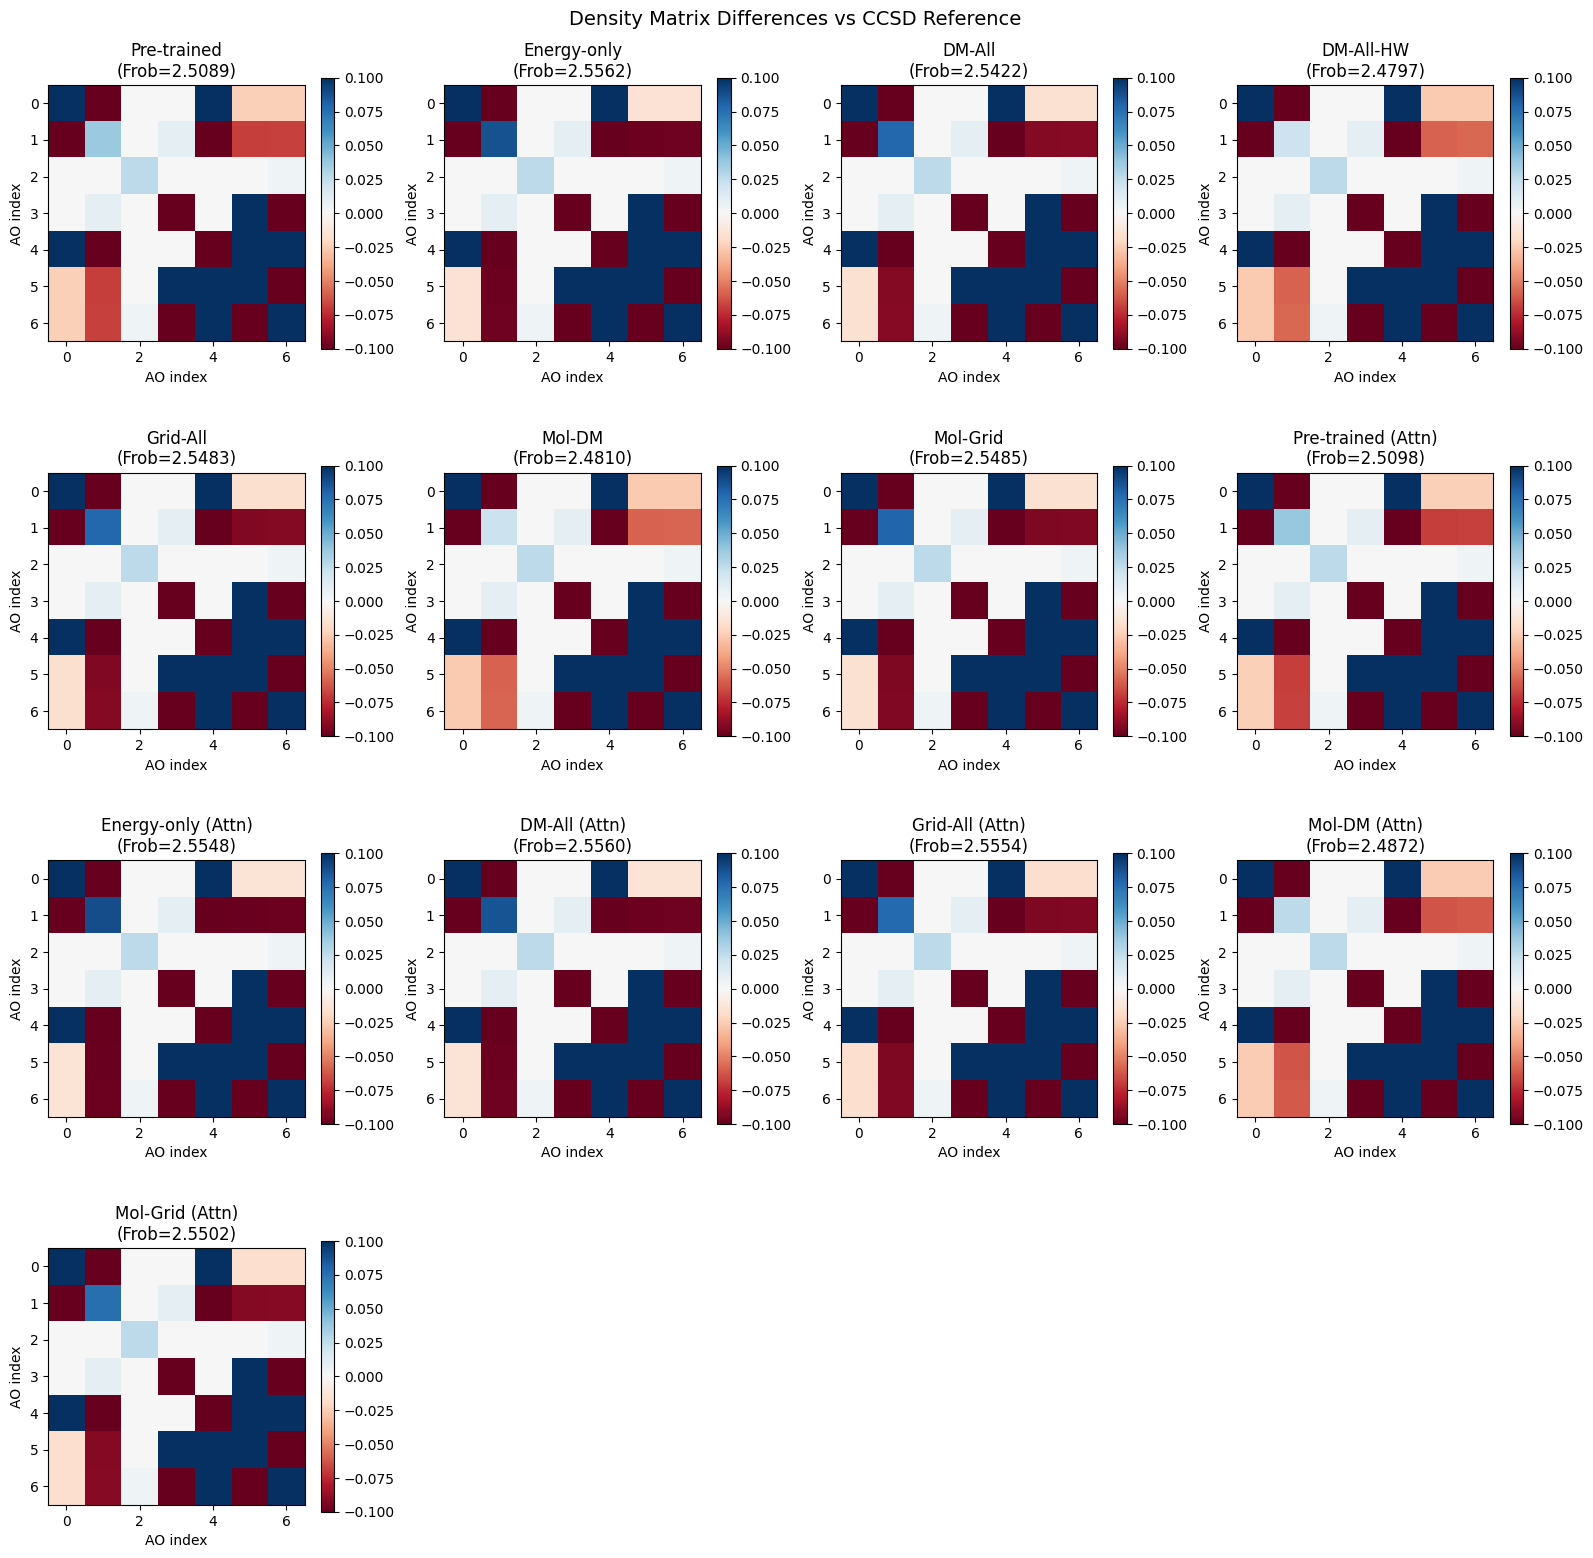

In [63]:
# Visualize density matrix differences
model_names = [name for name in results_dm.keys() if name != "PBE"]
n_models = len(model_names)
n_cols = min(4, n_models)
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
if n_rows == 1 and n_cols == 1:
    axes = [[axes]]
elif n_rows == 1:
    axes = [axes]
elif n_cols == 1:
    axes = [[ax] for ax in axes]

dm_ref_ccsd = ref_dms['H2O']

for idx, name in enumerate(model_names):
    row, col = idx // n_cols, idx % n_cols
    ax = axes[row][col] if n_rows > 1 else axes[0][col]
    
    dm_diff = results_dm[name] - dm_ref_ccsd
    im = ax.imshow(dm_diff, cmap='RdBu', vmin=-0.1, vmax=0.1)
    ax.set_title(f"{name}\n(Frob={dm_metrics[name]['frob_norm']:.4f})")
    ax.set_xlabel('AO index')
    ax.set_ylabel('AO index')
    plt.colorbar(im, ax=ax, shrink=0.8)

# Hide unused subplots
for idx in range(n_models, n_rows * n_cols):
    row, col = idx // n_cols, idx % n_cols
    if n_rows > 1:
        axes[row][col].axis('off')
    else:
        axes[0][col].axis('off')

plt.suptitle('Density Matrix Differences vs CCSD Reference', fontsize=14)
plt.tight_layout()
dm_fig_file = os.path.join(CHECKPOINT_BASE, 'dm_differences_all_models.png')
plt.savefig(dm_fig_file, dpi=150, bbox_inches='tight')
print(f"Saved DM difference figure to {dm_fig_file}")
plt.show()

Saved grid density figure to checkpoints_v2/grid_density_comparison_all_models.png


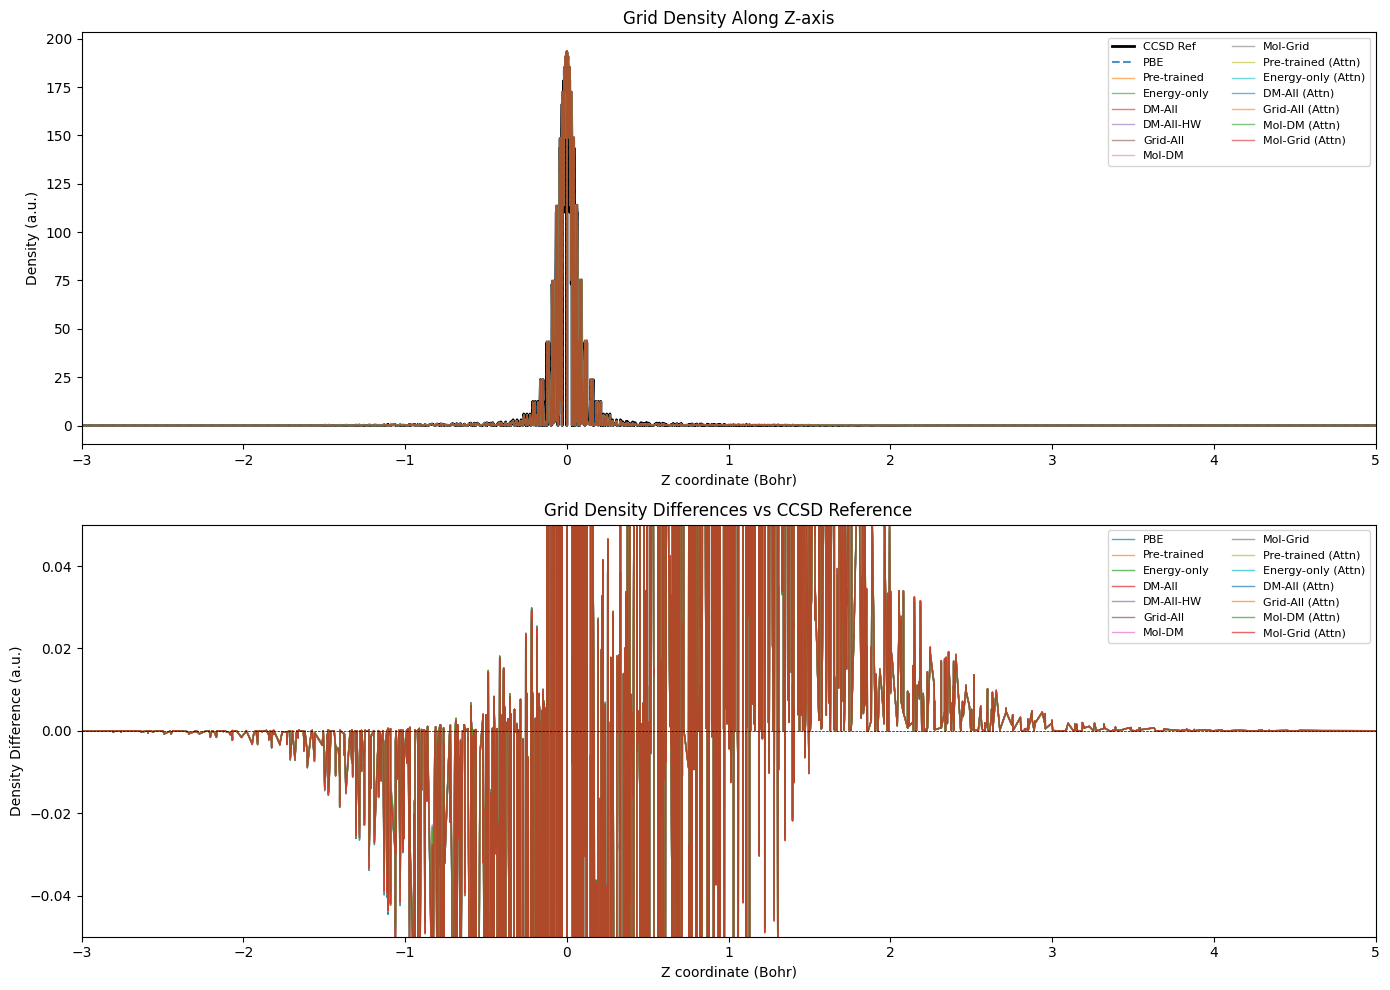

In [64]:
# Visualize grid density differences
# Plot density along a line through the molecule

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Get reference coordinates and density
rho_ref_ccsd = ref_densities['H2O']['rho']
coords_ref = ref_densities['H2O']['coords']

# Sort by z coordinate for line plot (molecule is in y-z plane)
z_coords = coords_ref[:, 2]
sort_idx = jnp.argsort(z_coords)

# Plot 1: Densities
ax1 = axes[0]
ax1.plot(z_coords[sort_idx], rho_ref_ccsd[sort_idx], 'k-', linewidth=2, label='CCSD Ref')

for name, (rho, coords, weights) in results_rho.items():
    if name == "PBE":
        ax1.plot(z_coords[sort_idx], rho[sort_idx], '--', linewidth=1.5, label=name, alpha=0.8)
    else:
        ax1.plot(z_coords[sort_idx], rho[sort_idx], '-', linewidth=1, label=name, alpha=0.6)

ax1.set_xlabel('Z coordinate (Bohr)')
ax1.set_ylabel('Density (a.u.)')
ax1.set_title('Grid Density Along Z-axis')
ax1.legend(loc='upper right', fontsize=8, ncol=2)
ax1.set_xlim(-3, 5)

# Plot 2: Density differences
ax2 = axes[1]
for name, (rho, coords, weights) in results_rho.items():
    rho_diff = rho - rho_ref_ccsd
    ax2.plot(z_coords[sort_idx], rho_diff[sort_idx], '-', linewidth=1, label=name, alpha=0.7)

ax2.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
ax2.set_xlabel('Z coordinate (Bohr)')
ax2.set_ylabel('Density Difference (a.u.)')
ax2.set_title('Grid Density Differences vs CCSD Reference')
ax2.legend(loc='upper right', fontsize=8, ncol=2)
ax2.set_xlim(-3, 5)
ax2.set_ylim(-0.05, 0.05)

plt.tight_layout()
rho_fig_file = os.path.join(CHECKPOINT_BASE, 'grid_density_comparison_all_models.png')
plt.savefig(rho_fig_file, dpi=150, bbox_inches='tight')
print(f"Saved grid density figure to {rho_fig_file}")
plt.show()

Saved summary figure to checkpoints_v2/summary_metrics_all_models.png


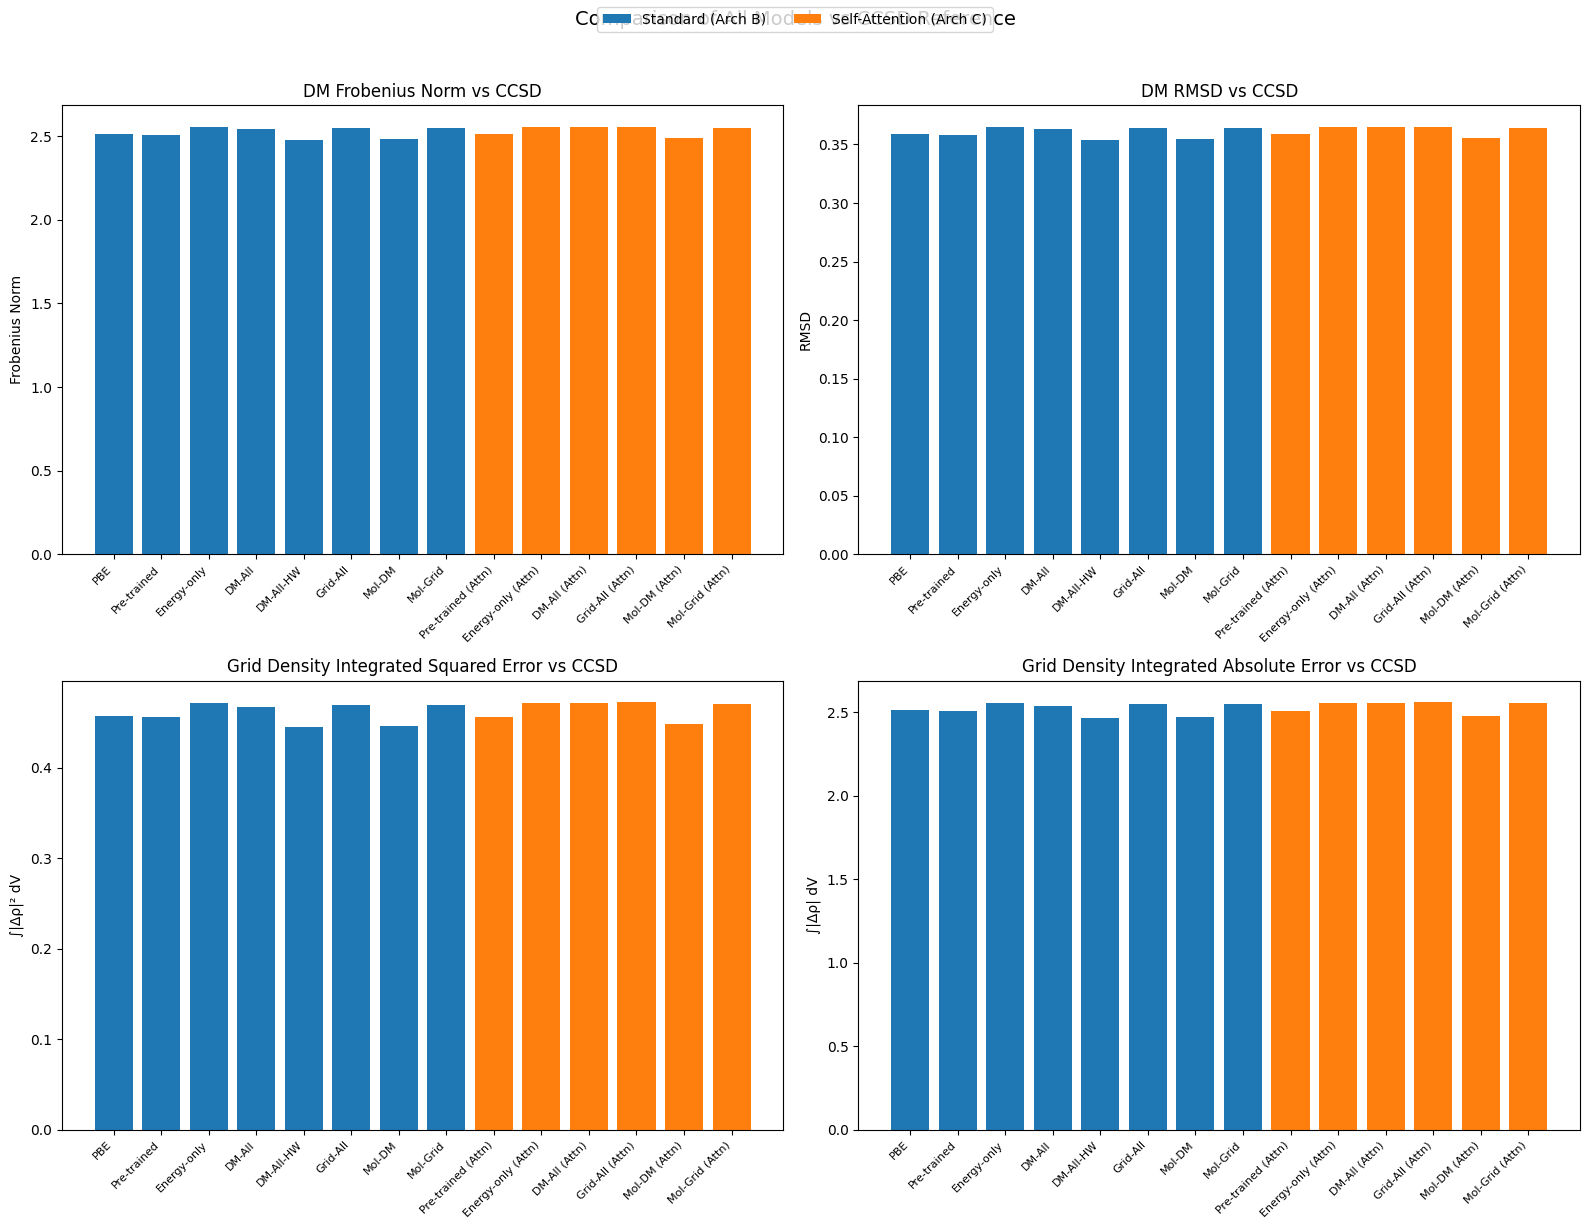


All results saved to: checkpoints_v2


In [65]:
# Summary bar chart comparing all metrics
model_names = list(dm_metrics.keys())
n_models = len(model_names)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: DM Frobenius Norm
ax1 = axes[0, 0]
frob_vals = [dm_metrics[name]['frob_norm'] for name in model_names]
bars1 = ax1.bar(range(n_models), frob_vals, color=['C0' if 'Attn' not in name else 'C1' for name in model_names])
ax1.set_xticks(range(n_models))
ax1.set_xticklabels(model_names, rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('Frobenius Norm')
ax1.set_title('DM Frobenius Norm vs CCSD')

# Plot 2: DM RMSD
ax2 = axes[0, 1]
rmsd_vals = [dm_metrics[name]['rmsd'] for name in model_names]
bars2 = ax2.bar(range(n_models), rmsd_vals, color=['C0' if 'Attn' not in name else 'C1' for name in model_names])
ax2.set_xticks(range(n_models))
ax2.set_xticklabels(model_names, rotation=45, ha='right', fontsize=8)
ax2.set_ylabel('RMSD')
ax2.set_title('DM RMSD vs CCSD')

# Plot 3: Grid Density Integrated Squared Error
ax3 = axes[1, 0]
int_sq_vals = [rho_metrics[name]['int_sq_err'] for name in model_names]
bars3 = ax3.bar(range(n_models), int_sq_vals, color=['C0' if 'Attn' not in name else 'C1' for name in model_names])
ax3.set_xticks(range(n_models))
ax3.set_xticklabels(model_names, rotation=45, ha='right', fontsize=8)
ax3.set_ylabel('∫|Δρ|² dV')
ax3.set_title('Grid Density Integrated Squared Error vs CCSD')

# Plot 4: Grid Density Integrated Absolute Error
ax4 = axes[1, 1]
int_abs_vals = [rho_metrics[name]['int_abs_err'] for name in model_names]
bars4 = ax4.bar(range(n_models), int_abs_vals, color=['C0' if 'Attn' not in name else 'C1' for name in model_names])
ax4.set_xticks(range(n_models))
ax4.set_xticklabels(model_names, rotation=45, ha='right', fontsize=8)
ax4.set_ylabel('∫|Δρ| dV')
ax4.set_title('Grid Density Integrated Absolute Error vs CCSD')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='C0', label='Standard (Arch B)'),
                   Patch(facecolor='C1', label='Self-Attention (Arch C)')]
fig.legend(handles=legend_elements, loc='upper center', ncol=2, fontsize=10)

plt.suptitle('Comparison of All Models vs CCSD Reference', fontsize=14, y=1.02)
plt.tight_layout()
summary_fig_file = os.path.join(CHECKPOINT_BASE, 'summary_metrics_all_models.png')
plt.savefig(summary_fig_file, dpi=150, bbox_inches='tight')
print(f"Saved summary figure to {summary_fig_file}")
plt.show()

print("\n" + "="*70)
print("All results saved to:", CHECKPOINT_BASE)
print("="*70)

---
## Saving and Loading Models

In [66]:
# Save final trained models to the final_models directory
FINAL_DIR = CHECKPOINT_DIRS['final_models']

print("=" * 60)
print("Saving Standard Networks (Architecture B)")
print("=" * 60)

# Save energy-trained networks
xnet_path = os.path.join(FINAL_DIR, 'xnet_energy_trained.eqx')
eqx.tree_serialise_leaves(xnet_path, xcmodel_trained.xnet)
cnet_path = os.path.join(FINAL_DIR, 'cnet_energy_trained.eqx')
eqx.tree_serialise_leaves(cnet_path, xcmodel_trained.cnet)
print(f"Saved energy-trained networks to {FINAL_DIR}/")

# Save DM-regularization-trained networks (low weight)
xnet_dm_path = os.path.join(FINAL_DIR, 'xnet_dm_reg_trained.eqx')
eqx.tree_serialise_leaves(xnet_dm_path, xcmodel_density_trained.xnet)
cnet_dm_path = os.path.join(FINAL_DIR, 'cnet_dm_reg_trained.eqx')
eqx.tree_serialise_leaves(cnet_dm_path, xcmodel_density_trained.cnet)
print(f"Saved DM-reg-trained (low weight) networks to {FINAL_DIR}/")

# Save DM-regularization-trained networks (high weight)
xnet_dm_hw_path = os.path.join(FINAL_DIR, 'xnet_dm_reg_hw_trained.eqx')
eqx.tree_serialise_leaves(xnet_dm_hw_path, xcmodel_density_trained_hw.xnet)
cnet_dm_hw_path = os.path.join(FINAL_DIR, 'cnet_dm_reg_hw_trained.eqx')
eqx.tree_serialise_leaves(cnet_dm_hw_path, xcmodel_density_trained_hw.cnet)
print(f"Saved DM-reg-trained (high weight) networks to {FINAL_DIR}/")

# Save grid-density-trained networks
xnet_grid_path = os.path.join(FINAL_DIR, 'xnet_grid_density_trained.eqx')
eqx.tree_serialise_leaves(xnet_grid_path, xcmodel_grid_density_trained.xnet)
cnet_grid_path = os.path.join(FINAL_DIR, 'cnet_grid_density_trained.eqx')
eqx.tree_serialise_leaves(cnet_grid_path, xcmodel_grid_density_trained.cnet)
print(f"Saved grid-density-trained networks to {FINAL_DIR}/")

print("\n" + "=" * 60)
print("Saving Self-Attention Networks (Architecture C)")
print("=" * 60)

# Save pre-trained self-attention networks
xnet_pretrain_attn_path = os.path.join(FINAL_DIR, 'xnet_pretrained_attn.eqx')
eqx.tree_serialise_leaves(xnet_pretrain_attn_path, xnet_C_trained)
cnet_pretrain_attn_path = os.path.join(FINAL_DIR, 'cnet_pretrained_attn.eqx')
eqx.tree_serialise_leaves(cnet_pretrain_attn_path, cnet_C_trained)
print(f"Saved pre-trained self-attention networks to {FINAL_DIR}/")

# Save energy-trained self-attention networks
xnet_energy_attn_path = os.path.join(FINAL_DIR, 'xnet_energy_trained_attn.eqx')
eqx.tree_serialise_leaves(xnet_energy_attn_path, xcmodel_attn_trained.xnet)
cnet_energy_attn_path = os.path.join(FINAL_DIR, 'cnet_energy_trained_attn.eqx')
eqx.tree_serialise_leaves(cnet_energy_attn_path, xcmodel_attn_trained.cnet)
print(f"Saved energy-trained self-attention networks to {FINAL_DIR}/")

# Save DM-reg-trained self-attention networks
xnet_dm_attn_path = os.path.join(FINAL_DIR, 'xnet_dm_reg_trained_attn.eqx')
eqx.tree_serialise_leaves(xnet_dm_attn_path, xcmodel_density_attn_trained.xnet)
cnet_dm_attn_path = os.path.join(FINAL_DIR, 'cnet_dm_reg_trained_attn.eqx')
eqx.tree_serialise_leaves(cnet_dm_attn_path, xcmodel_density_attn_trained.cnet)
print(f"Saved DM-reg-trained self-attention networks to {FINAL_DIR}/")

# Save grid-density-trained self-attention networks
xnet_grid_attn_path = os.path.join(FINAL_DIR, 'xnet_grid_density_trained_attn.eqx')
eqx.tree_serialise_leaves(xnet_grid_attn_path, xcmodel_grid_density_attn_trained.xnet)
cnet_grid_attn_path = os.path.join(FINAL_DIR, 'cnet_grid_density_trained_attn.eqx')
eqx.tree_serialise_leaves(cnet_grid_attn_path, xcmodel_grid_density_attn_trained.cnet)
print(f"Saved grid-density-trained self-attention networks to {FINAL_DIR}/")

print(f"\nAll final models saved to: {FINAL_DIR}/")
print("\nTo load the trained networks:")
print("# Standard networks (Architecture B)")
print(f"  xnet_loaded = eqx.tree_deserialise_leaves('{xnet_path}', xnet_B)")
print(f"  cnet_loaded = eqx.tree_deserialise_leaves('{cnet_path}', cnet_B)")
print("\n# Self-attention networks (Architecture C)")
print(f"  xnet_attn_loaded = eqx.tree_deserialise_leaves('{xnet_energy_attn_path}', xnet_C)")
print(f"  cnet_attn_loaded = eqx.tree_deserialise_leaves('{cnet_energy_attn_path}', cnet_C)")

Saving Standard Networks (Architecture B)
Saved energy-trained networks to checkpoints_v2/09_final_models/
Saved DM-reg-trained (low weight) networks to checkpoints_v2/09_final_models/
Saved DM-reg-trained (high weight) networks to checkpoints_v2/09_final_models/
Saved grid-density-trained networks to checkpoints_v2/09_final_models/

Saving Self-Attention Networks (Architecture C)
Saved pre-trained self-attention networks to checkpoints_v2/09_final_models/
Saved energy-trained self-attention networks to checkpoints_v2/09_final_models/
Saved DM-reg-trained self-attention networks to checkpoints_v2/09_final_models/
Saved grid-density-trained self-attention networks to checkpoints_v2/09_final_models/

All final models saved to: checkpoints_v2/09_final_models/

To load the trained networks:
# Standard networks (Architecture B)
  xnet_loaded = eqx.tree_deserialise_leaves('checkpoints_v2/09_final_models/xnet_energy_trained.eqx', xnet_B)
  cnet_loaded = eqx.tree_deserialise_leaves('checkpoint

---
## Summary

This notebook demonstrated:

### Network Architectures Compared:

1. **Architecture A**: Shallow network (depth=2, nodes=8) - baseline
2. **Architecture B**: Deeper network (depth=3, nodes=16) - standard MLP
3. **Architecture C**: Deeper network with self-attention (depth=3, nodes=16, attention=True)
4. **Architecture D**: Deeper network with log-transformed inputs (depth=3, nodes=16, transform=True)
5. **Architecture E**: Deeper network with log-transforms + self-attention (depth=3, nodes=16, transform=True, attention=True)

### Training Approaches Compared:

1. **Pre-training on Enhancement Factors**: Train networks to reproduce PBE exchange (Fx) and correlation (Fc) enhancement factors
2. **Energy-Only Training**: Fine-tune on total energies using pyscf-ad autodiff through SCF
3. **Energy + Density Regularization**: Add density matrix error penalty to improve density predictions
4. **Grid Density Training**: Use actual grid density for more direct density supervision

### Log-Transform Feature (Architectures D, E):

The log-transformed networks apply numerical transformations to the input descriptors:
- Exchange: `x1 = (1 - exp(-s²)) * log(s + 1)` where s is the reduced density gradient
- Correlation: `x0 = log(rho^(1/3) + 1e-5)`, `x1 = (1 - exp(-s²)) * log(s + 1)`

These transformations improve numerical stability and can help with training dynamics.

### Self-Attention Feature (Architectures C, E):

The self-attention layer is inserted after the first hidden layer of the MLP. This allows the network to:
- Learn dynamic feature interactions between grid points
- Weight the importance of different input features adaptively
- Potentially capture non-local correlations in the density

### Key Implementation Details:

- Networks are pre-trained on enhancement factor data from reference PBE calculations
- Training uses pyscf-ad for automatic differentiation through the SCF cycle
- The `ReferenceXCModel` wrapper integrates xcquinox networks with pyscf-ad
- All models are checkpointed for reproducibility

### Key Points for Production Use:

1. Pre-training on enhancement factors provides a good initialization
2. Energy-only training is fast but may not improve density predictions
3. Density regularization helps balance energy and density accuracy
4. Grid density training provides the most direct density supervision
5. Self-attention adds flexibility but increases computational cost
6. Log-transforms can improve numerical stability for certain density ranges
